# E39 · How old is it? Radiocarbon calibration and Bayesian chronologies

| | |
|---|---|
| **Type** | Advanced worked example - read, run, modify |
| **Data** | The **IntCal20** radiocarbon calibration curve (Reimer et al. 2020) · all 49 individual measurements from the 1988 **Shroud of Turin** dating by Arizona, Oxford and Zurich, on the shroud and three known-age control textiles (Damon et al. 1989, Table 1) · 31 radiocarbon dates down the peat core of **Sluggan Bog**, Northern Ireland (Smith & Goddard 1991, via the R package Bchron) |
| **You will learn** | Why a radiocarbon age is not a calendar age · **calibration** as a likelihood through a wiggly curve that has its own uncertainty · multimodal calendar posteriors and **plateaus** (the Hallstatt plateau) · why NUTS fails on a single calibrated date (r_hat far above 1, zero divergences) and why a **1-D grid** is exact · **integrating the calendar date out on a grid inside a PyMC model** so NUTS only sees smooth parameters · a **hierarchical inter-laboratory model** (lab offsets, lab-by-sample heterogeneity) anchored by known-age controls, and the 1989 chi-square debate as a posterior predictive check · a **Bayesian chronology**: OxCal-style sequence of phases with boundaries (Dirichlet spacings), dates integrated analytically within their phases · an **outlier model** that also rescues the sampler · how stratigraphic order sharpens dates; phase boundaries and durations · explaining it to everyone: the "shadow" of a lab number on the calendar, a timeline with a probability ribbon, 20 equally likely dates, "how much of the carbon would have to be fake", and an animation of plausible histories |

## The question, in one paragraph

Living things take in carbon from the air, including a tiny, slowly decaying radioactive
kind. After death the clock starts: measure how much is left and you know how long ago the
plant or animal died. In 1988 three laboratories did this with a postage-stamp-sized piece of
the **Shroud of Turin**, the linen cloth many believe wrapped the body of Jesus. They reported
that the flax was harvested between AD 1260 and 1390. **How sure can we be - and could the
cloth still be from the first century?** The catch is that the radioactive clock does not run
at a steady speed through history: the amount of radiocarbon in the air has wobbled, so a lab
measurement has to be translated into a calendar date through a wiggly "exchange-rate" curve.
Sometimes that translation is sharp, sometimes it smears one measurement over centuries. In
the second half we see how archaeologists and geologists beat the smear: when samples come
from layers that must be in order - deeper is older - the order itself sharpens every date.

## The technical plan

A radiocarbon laboratory reports a **conventional radiocarbon age** (in "14C years BP", before
1950) with a standard error. The true calendar date $\theta$ enters only through the
**calibration curve**, $\mu(\theta) \pm s(\theta)$: the radiocarbon age that material of
calendar age $\theta$ would have, measured on tree rings of known age (IntCal20, Reimer et al.
2020, *Radiocarbon* 62). Calibration is Bayes' theorem through that curve (Bronk Ramsey 2009,
*Radiocarbon* 51; Buck, Cavanagh & Litton 1996):

$$p(\theta \mid y) \propto p(\theta)\, \mathcal N\bigl(y \mid \mu(\theta),\ \sigma^2 + s(\theta)^2\bigr).$$

Because $\mu$ wiggles, the posterior is often multimodal, and the likelihood surface is a
gradient-based sampler's nightmare. Our strategy throughout: **the calendar date is one-
dimensional, so integrate it out exactly on a grid**, and let NUTS handle only the smooth
parameters around it (laboratory offsets, phase boundaries, outlier rates).

In [1]:
import bz2
import gzip
import json
import logging
import lzma
import struct
from pathlib import Path

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.io as pio
import pymc as pm
import pytensor.tensor as pt
from IPython.display import HTML, display
from matplotlib import animation
from matplotlib.patches import Ellipse, Rectangle

from pymc_challenges import data

RANDOM_SEED = 1988
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
pio.renderers.default = "plotly_mimetype+notebook_connected"
logging.getLogger("pymc").setLevel(logging.WARNING)

# One hue per role: radiocarbon (lab) scale, calendar scale, the sequence model; grey for data.
C14, CAL, SEQ, GREY, INK = "#7b3294", "#d6452a", "#2a78d6", "#8a8a86", "#222222"
LABS = ["Arizona", "Oxford", "Zurich"]
LAB_COL = {"Arizona": "#e08214", "Oxford": "#2a78d6", "Zurich": "#1b9e77"}


def ad_label(year):
    """Astronomical year (0 = 1 BC) -> 'AD 1260' / '250 BC'."""
    year = int(round(year))
    return f"AD {year}" if year > 0 else f"{1 - year} BC"


print(f"PyMC {pm.__version__}, ArviZ {az.__version__}")

PyMC 6.3.2, ArviZ 1.3.0


## 1 · The calibration curve

IntCal20 gives, for every calendar year back to 55,000 years ago, the radiocarbon age that a
sample of that age should show, with a 1-sd band. Calendar ages are in **cal BP** (calendar
years before 1950). We convert to AD with $\text{AD} = 1950 - \text{BP}$ and use astronomical
year numbering, where year 0 is 1 BC.

In [2]:
data.describe("intcal20")
curve = data.load("intcal20").sort_values("cal_bp").reset_index(drop=True)
print(curve.shape, "rows; calendar step (years) by range:",
      {f"{lo}-{hi} cal BP": sorted(np.unique(np.diff(curve.cal_bp[(curve.cal_bp >= lo) & (curve.cal_bp <= hi)])).tolist())
       for lo, hi in [(0, 14000), (14000, 15000), (15000, 25000), (25000, 55000)]})
curve.head(3)

intcal20: Calibration curve on a calendar grid (5-yr steps in the Holocene, coarser further back): calendar age (cal BP, years before 1950), radiocarbon age (14C yr BP) and its 1-sd uncertainty, and Delta-14C (per mil) with its 1-sd uncertainty. Rows run from 55,000 cal BP down to 0.
  source: Reimer et al. (2020), The IntCal20 Northern Hemisphere radiocarbon age calibration curve (0-55 cal kBP), Radiocarbon 62:725-757, doi:10.1017/RDC.2020.41; distributed by intcal.org.
  url:    https://intcal.org/curves/intcal20.14c
(9501, 5) rows; calendar step (years) by range: {'0-14000 cal BP': [1, 5], '14000-15000 cal BP': [5], '15000-25000 cal BP': [10], '25000-55000 cal BP': [20]}


,cal_bp,c14_bp,c14_sd,delta14c,delta14c_sd
0,0,199,11,-24.5,1.4
1,1,197,11,-24.1,1.4
2,2,195,11,-23.8,1.4


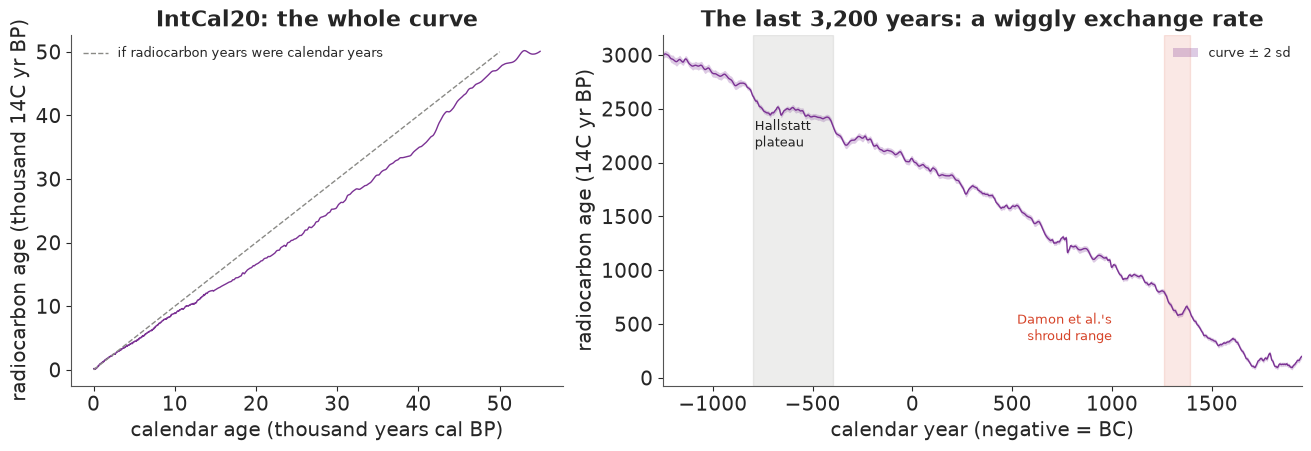

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), gridspec_kw={"width_ratios": [1, 1.3]})
ax = axes[0]
ax.plot(curve.cal_bp / 1000, curve.c14_bp / 1000, color=C14, lw=1)
ax.plot([0, 50], [0, 50], color=GREY, ls="--", lw=1, label="if radiocarbon years were calendar years")
ax.set(xlabel="calendar age (thousand years cal BP)", ylabel="radiocarbon age (thousand 14C yr BP)",
       title="IntCal20: the whole curve")
ax.legend(fontsize=9)
ax = axes[1]
z = curve[(curve.cal_bp >= 0) & (curve.cal_bp <= 3200)]
ad = 1950 - z.cal_bp
ax.fill_between(ad, z.c14_bp - 2 * z.c14_sd, z.c14_bp + 2 * z.c14_sd, color=C14, alpha=0.25, lw=0,
                label="curve ± 2 sd")
ax.plot(ad, z.c14_bp, color=C14, lw=1)
ax.axvspan(-800, -400, color=GREY, alpha=0.15)
ax.text(-790, 2150, "Hallstatt\nplateau", fontsize=9, color=INK)
ax.axvspan(1260, 1390, color=CAL, alpha=0.12)
ax.text(1000, 350, "Damon et al.'s\nshroud range", fontsize=9, color=CAL, ha="right")
ax.set(xlabel="calendar year (negative = BC)", ylabel="radiocarbon age (14C yr BP)",
       title="The last 3,200 years: a wiggly exchange rate", xlim=(-1250, 1950))
ax.legend(loc="upper right", fontsize=9);

Two features matter for everything that follows. On the left, radiocarbon years are not
calendar years: 50,000 radiocarbon years correspond to 55,000 calendar years, and the
relation bends. On the right, the curve **wiggles**, and in places it is **flat**: between
about 750 and 400 BC (the *Hallstatt plateau*, named after the Iron Age culture it plagues)
the radiocarbon age hardly changes for three centuries, so a measurement there cannot
distinguish 750 BC from 400 BC however precise the laboratory is.

> **In plain words:** A lab does not measure a date; it measures how much radiocarbon is
> left. Turning that into a year needs a conversion table built from tree rings, and the
> table is bumpy - some centuries all "look the same" to radiocarbon.

## 2 · Calibrating one date on a grid

For a single date the posterior lives on one axis, so we simply evaluate it on every calendar
year and normalise: exact, up to the 1-year grid. The curve is interpolated linearly between
its 5-year nodes. We use a flat prior over 1000 BC to AD 1900.

In [4]:
YEAR = np.arange(-1000, 1901)                 # astronomical years: 0 = 1 BC
MU_Y = np.interp(1950 - YEAR, curve.cal_bp, curve.c14_bp)
S_Y = np.interp(1950 - YEAR, curve.cal_bp, curve.c14_sd)


def calibrate(age, sd, year=YEAR, mu=MU_Y, s=S_Y):
    """Posterior probability of each calendar year (flat prior) for one radiocarbon age."""
    v = sd**2 + s**2
    lp = -0.5 * (age - mu) ** 2 / v - 0.5 * np.log(v)
    p = np.exp(lp - lp.max())
    return p / p.sum()


def hpd_ranges(p, year=YEAR, prob=0.95):
    """Highest-posterior-density region of a grid posterior, as a list of (from, to) years."""
    order = np.argsort(p)[::-1]
    keep = np.zeros(len(p), bool)
    keep[order[: np.searchsorted(np.cumsum(p[order]), prob) + 1]] = True
    edges = np.flatnonzero(np.diff(np.r_[0, keep.astype(int), 0]))
    return [(int(year[a]), int(year[b - 1])) for a, b in zip(edges[::2], edges[1::2])]


def fmt_ranges(ranges):
    return ", ".join(f"{ad_label(a)}-{ad_label(b)[3:] if a > 0 else ad_label(b)}" for a, b in ranges)


examples = {"Shroud, pooled (Damon et al.): 691 ± 31": (691, 31),
            "A date on the Hallstatt plateau: 2450 ± 25": (2450, 25),
            "Cope of St Louis d'Anjou (control): 724 ± 20": (724, 20)}
for name, (a, e) in examples.items():
    p = calibrate(a, e)
    print(f"{name:<46} 95% HPD: {fmt_ranges(hpd_ranges(p))}")

Shroud, pooled (Damon et al.): 691 ± 31        95% HPD: AD 1273-1317, AD 1360-1388
A date on the Hallstatt plateau: 2450 ± 25     95% HPD: 750 BC-684 BC, 667 BC-634 BC, 622 BC-613 BC, 591 BC-414 BC
Cope of St Louis d'Anjou (control): 724 ± 20   95% HPD: AD 1268-1297


The shroud's pooled date, 691 ± 31 radiocarbon years, calibrates to **two** separate ranges -
the same double range Damon et al. reported with the "intercept" method in 1989 (AD
1262-1312 and 1353-1384 on the calibration curve of the day; IntCal20 moves the ends by a few
years). The plateau date, with a smaller error, spreads over more than three centuries. The
cope's date lands on a steep part of the curve and calibrates to a range narrower than its
own error. The figure shows how: the lab's bell curve on the radiocarbon axis "casts a
shadow" through the calibration curve onto the calendar axis.

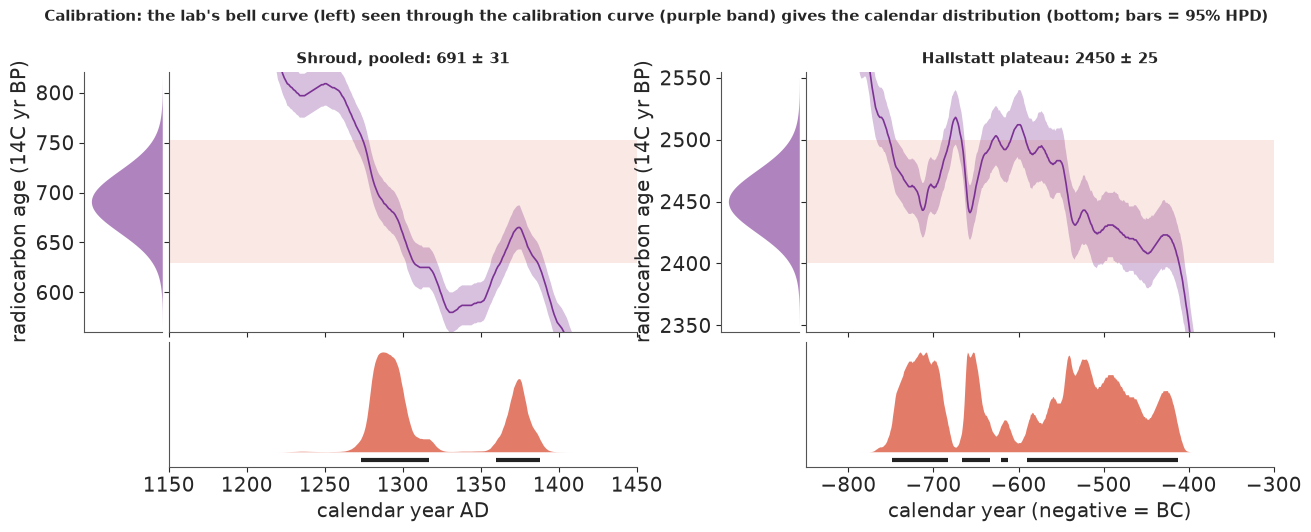

In [5]:
def shadow_panel(ax_main, ax_left, ax_bottom, age, sd, xlim, color=CAL, label=None):
    m = (YEAR >= xlim[0]) & (YEAR <= xlim[1])
    ax_main.fill_between(YEAR[m], MU_Y[m] - 2 * S_Y[m], MU_Y[m] + 2 * S_Y[m], color=C14, alpha=0.3, lw=0)
    ax_main.plot(YEAR[m], MU_Y[m], color=C14, lw=1.2)
    ax_main.axhspan(age - 2 * sd, age + 2 * sd, color=color, alpha=0.12, lw=0)
    yy = np.linspace(age - 4 * sd, age + 4 * sd, 200)
    ax_left.fill_betweenx(yy, 0, np.exp(-0.5 * ((yy - age) / sd) ** 2), color=C14, alpha=0.6, lw=0)
    p = calibrate(age, sd)
    ax_bottom.fill_between(YEAR[m], 0, p[m], color=color, alpha=0.7, lw=0)
    for a, b in hpd_ranges(p):
        ax_bottom.plot([a, b], [-p.max() * 0.08] * 2, color=INK, lw=3, solid_capstyle="butt")
    ax_bottom.set(xlim=xlim, ylim=(-p.max() * 0.15, p.max() * 1.1), yticks=[], xlabel="calendar year AD")
    ax_left.set(xticks=[], xlim=(1.1, 0), ylabel="radiocarbon age (14C yr BP)")
    ax_main.set(xlim=xlim, ylim=ax_left.get_ylim())
    ax_main.tick_params(labelbottom=False, labelleft=False)
    if label:
        ax_main.set_title(label, fontsize=11)


fig = plt.figure(figsize=(13, 5.2), layout="none")
for col, (name, (a, e), xlim) in enumerate([
        ("Shroud, pooled: 691 ± 31", (691, 31), (1150, 1450)),
        ("Hallstatt plateau: 2450 ± 25", (2450, 25), (-850, -300))]):
    x0 = 0.06 + col * 0.49
    ax_left = fig.add_axes([x0, 0.36, 0.06, 0.5])
    ax_main = fig.add_axes([x0 + 0.065, 0.36, 0.36, 0.5])
    ax_bot = fig.add_axes([x0 + 0.065, 0.1, 0.36, 0.24])
    shadow_panel(ax_main, ax_left, ax_bot, a, e, xlim, label=name)
    ax_left.set_ylim(a - 4.2 * e, a + 4.2 * e)
    ax_main.set_ylim(a - 4.2 * e, a + 4.2 * e)
    if col == 1:
        ax_bot.set_xlabel("calendar year (negative = BC)")
fig.suptitle("Calibration: the lab's bell curve (left) seen through the calibration curve (purple band) "
             "gives the calendar distribution (bottom; bars = 95% HPD)", fontsize=11);

> **In plain words:** The shroud measurement points to two stretches of history, one around
> 1260-1310 and another around 1350-1390, because the conversion curve passes through the
> measured value twice. A measurement in the Iron Age can be hopeless: the curve is flat, so
> anywhere in 750-400 BC fits equally well.

## 3 · Why not just use NUTS?

The obvious PyMC model makes the calendar date a continuous parameter and interpolates the
curve with `pytensor`. It compiles, it samples in two seconds, it reports zero divergences -
and it is wrong.

In [6]:
MU_T, S_T = pt.as_tensor(MU_Y), pt.as_tensor(S_Y)


def curve_at(theta):
    """Linear interpolation of the curve (mean and sd) at a continuous calendar year."""
    x = theta - YEAR[0]
    i0 = pt.clip(pt.cast(pt.floor(x), "int64"), 0, len(YEAR) - 2)
    f = x - i0
    return MU_T[i0] * (1 - f) + MU_T[i0 + 1] * f, S_T[i0] * (1 - f) + S_T[i0 + 1] * f


with pm.Model() as single_model:
    year = pm.Uniform("year", -1000.0, 1900.0)
    mu_t, s_t = curve_at(year)
    pm.Normal("y", mu_t, pt.sqrt(31.0**2 + s_t**2), observed=691.0)
    single_idata = pm.sample(random_seed=RANDOM_SEED, progressbar=False)

draws_single = single_idata.posterior["year"].to_numpy()
p_shroud_pooled = calibrate(691, 31)
print(f"divergences: {int(single_idata.sample_stats['diverging'].sum())}, "
      f"r_hat: {float(az.rhat(single_idata)['year']):.2f}, ESS: {float(az.ess(single_idata)['year']):.0f}")
for c in range(draws_single.shape[0]):
    print(f"  chain {c}: median {ad_label(np.median(draws_single[c]))}, "
          f"90% range {ad_label(np.quantile(draws_single[c], 0.05))} to {ad_label(np.quantile(draws_single[c], 0.95))}")
print(f"exact grid posterior: median {ad_label(YEAR[np.searchsorted(np.cumsum(p_shroud_pooled), 0.5)])}")

divergences: 0, r_hat: 2.85, ESS: 5
  chain 0: median AD 90, 90% range AD 88 to AD 91
  chain 1: median AD 1290, 90% range AD 1277 to AD 1305
  chain 2: median AD 494, 90% range AD 489 to AD 495
  chain 3: median 21 BC, 90% range 22 BC to 19 BC
exact grid posterior: median AD 1297


Each chain sits in a different place, most of them centuries away from the real answer, and
none moves. r_hat catches it; divergences do not. What went wrong:

- **Local modes everywhere.** The likelihood through a wiggly curve has a local maximum at
  every wiggle that comes *closest* to the measurement, even where it is 10-20 standard
  errors away. A chain initialised there climbs to the nearest wiggle and stays: the valleys
  between wiggles are hundreds of log units deep.
- **Gradients from a piecewise-linear curve** are piecewise constant and jump at every node,
  so the leapfrog integrator's energy error is noisy even inside the right mode.

Smoothing the curve or tempering would help a little. For radiocarbon the right move is
simpler: **the calendar date is one-dimensional, so never sample it - integrate it**. On a
1-year grid a sum over 2,900 years is exact to plotting precision and costs nothing. Whenever
a model has more structure (laboratory offsets, stratigraphic order), we will sum each date
out on the grid inside the model, and let NUTS see only parameters on which the likelihood is
smooth. The calendar dates are then recovered afterwards, exactly, from their grid
conditional distributions.

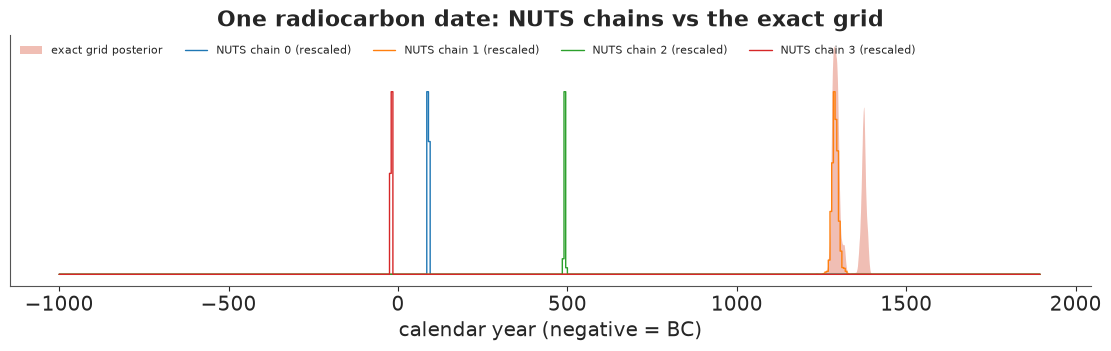

In [7]:
fig, ax = plt.subplots(figsize=(11, 3.4))
ax.fill_between(YEAR, 0, p_shroud_pooled, color=CAL, alpha=0.35, lw=0, label="exact grid posterior")
for c in range(draws_single.shape[0]):
    h, edges = np.histogram(draws_single[c], bins=np.arange(-1000, 1901, 5), density=True)
    ax.step(edges[:-1], h / h.max() * p_shroud_pooled.max() * 0.8, color=plt.cm.tab10(c), lw=1,
            where="post", label=f"NUTS chain {c} (rescaled)")
ax.set(xlabel="calendar year (negative = BC)", yticks=[], title="One radiocarbon date: NUTS chains vs the exact grid")
ax.legend(fontsize=8, ncol=5, loc="upper left");

## 4 · The Shroud of Turin data

In April 1988 a strip was cut from the shroud and split between three accelerator
laboratories, together with three textiles of **known age** as controls (the laboratories
knew their approximate ages): linen from an Islamic-Christian-era tomb at Qasr Ibrîm in Nubia
(11th-12th century AD), linen associated with an early 2nd-century-AD mummy from Thebes
(radiocarbon-dated earlier by the British Museum to the 1st century BC - 1st century AD), and
threads from the cope of St Louis d'Anjou (c. AD 1290-1310). Each laboratory measured
several subsamples with different cleaning treatments. We use every individual measurement,
transcribed from Table 1 of Damon et al. (1989, *Nature* 337).

In [8]:
data.describe("shroud_damon1989")
d = data.load("shroud_damon1989")
TEXTILES = ["shroud", "Nubia", "mummy", "cope"]
d["textile"] = [TEXTILES[s - 1] for s in d["sample"]]
lab_i = pd.Index(LABS).get_indexer(d["lab"])
smp_i = d["sample"].to_numpy() - 1
assert (lab_i >= 0).all()
y_obs, sd_obs = d.age_bp.to_numpy(float), d.sd.to_numpy(float)
w_obs = 1 / sd_obs**2


def lab_means(y, sd, smp, lab):
    """Inverse-variance weighted mean and its error for every (sample, lab) cell."""
    w = 1 / sd**2
    num, den = np.zeros((4, 3)), np.zeros((4, 3))
    np.add.at(num, (smp, lab), w * y)
    np.add.at(den, (smp, lab), w)
    return num / den, den ** -0.5


def ward_wilson_T(m, e):
    """Chi-square statistic of the three lab means around their weighted mean (2 d.f.)."""
    w = 1 / e**2
    pooled = (w * m).sum(-1, keepdims=True) / w.sum(-1, keepdims=True)
    return (w * (m - pooled) ** 2).sum(-1)


M_obs, E_obs = lab_means(y_obs, sd_obs, smp_i, lab_i)
T_obs = ward_wilson_T(M_obs, E_obs)
print(pd.crosstab(d.textile, d.lab).loc[TEXTILES])
pd.DataFrame({f"{lab} mean": M_obs[:, j].round() for j, lab in enumerate(LABS)} |
             {f"{lab} error": E_obs[:, j].round() for j, lab in enumerate(LABS)} |
             {"chi-square (2 df)": T_obs.round(1)}, index=TEXTILES)

shroud_damon1989: All 49 individual AMS measurements (14C yr BP, 1 sd) by the three laboratories (Arizona, Oxford, Zurich) on sample 1 (the Shroud of Turin) and three known-age controls: 2 = linen from a tomb at Qasr Ibrim, Nubia (11th-12th century AD), 3 = linen associated with an early 2nd-century AD mummy of Cleopatra from Thebes, 4 = threads from the cope of St Louis d'Anjou, Saint-Maximin (c. AD 1290-1310). meas_id is the paper's code (lab, sample, run, pretreatment, replicate).
  source: Damon et al. (1989), Radiocarbon dating of the Shroud of Turin, Nature 337:611-615, doi:10.1038/337611a0. HAND-TRANSCRIBED from Table 1 ('Basic data, individual measurements') of the paper; the URL is the full text of the paper (HTML) at shroud.com, not a CSV, so keep the cached file in data/. The 12 shroud rows were cross-checked against the `shroud` data of the CRAN package rice (Blaauw), and the per-lab weighted means reproduce Table 2.
  url:    https://www.shroud.com/nature.htm
lab      Ariz

,Arizona mean,Oxford mean,Zurich mean,Arizona error,Oxford error,Zurich error,chi-square (2 df)
shroud,646.0,749.0,676.0,17.0,31.0,24.0,8.6
Nubia,927.0,938.0,941.0,20.0,29.0,23.0,0.2
mummy,1995.0,1977.0,1940.0,20.0,33.0,28.0,2.5
cope,722.0,756.0,685.0,20.0,26.0,25.0,3.9


Our weighted lab means reproduce Damon et al.'s Table 2 (646, 750, 676 for the shroud; the
Oxford values differ by a year or two; the paper's footnotes mention an adjusted Oxford
replicate and Oxford's rounding of small errors up to 40). One detail matters:
for its shroud mean Arizona quoted an error of **±31**, not the ±17 the four individual
errors imply, and with the paper's errors the shroud's chi-square is 6.4 (p = 0.04), the
number behind thirty years of argument about whether the three labs really agree. With the
errors implied by the individual measurements, the disagreement looks stronger still (the
value above). The controls agree well.

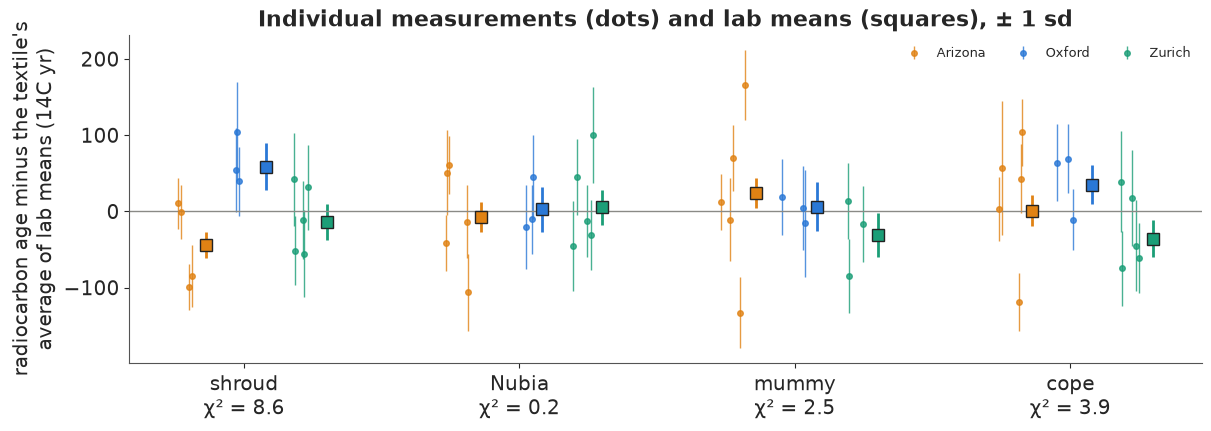

In [9]:
fig, ax = plt.subplots(figsize=(12, 4.2))
xpos = {t: i for i, t in enumerate(TEXTILES)}
for j, lab in enumerate(LABS):
    sub = d[d.lab == lab]
    xs = sub.textile.map(xpos).to_numpy() + (j - 1) * 0.22 + rng.uniform(-0.05, 0.05, len(sub))
    ax.errorbar(xs, sub.age_bp - sub.textile.map(dict(zip(TEXTILES, M_obs.mean(1)))), yerr=sub.sd, fmt="o",
                ms=4, color=LAB_COL[lab], alpha=0.8, lw=1, label=lab)
    ax.errorbar(np.arange(4) + (j - 1) * 0.22 + 0.08, M_obs[:, j] - M_obs.mean(1), yerr=E_obs[:, j],
                fmt="s", ms=8, color=LAB_COL[lab], mec=INK, lw=2)
ax.axhline(0, color=GREY, lw=1)
ax.set_xticks(range(4), [f"{t}\nχ² = {T:.1f}" for t, T in zip(TEXTILES, T_obs)])
ax.set(ylabel="radiocarbon age minus the textile's\naverage of lab means (14C yr)",
       title="Individual measurements (dots) and lab means (squares), ± 1 sd")
ax.legend(ncol=3, fontsize=9);

On the shroud, Arizona's four measurements sit low and Oxford's three high; on the controls
the labs overlap. Is that a shroud-specific problem (a heterogeneous or contaminated sample),
a laboratory bias that also shows on the controls, or chance? A single chi-square cannot tell
these apart; a hierarchical model can.

## 5 · A hierarchical model of three laboratories and four textiles

For measurement $k$ of textile $i$ by laboratory $j$:

$$y_k = c_i + \delta_j + \eta_{ij} + \varepsilon_k,\qquad \varepsilon_k \sim \mathcal N(0, \sigma_k^2),$$

- $c_i \sim \mathcal N(\mu(\theta_i), s(\theta_i)^2)$: the textile's true radiocarbon age, the
  calibration curve at its calendar date $\theta_i$ (shared by every measurement of it);
- $\delta_j \sim \mathcal N(0, \omega^2)$: a persistent **laboratory offset**;
- $\eta_{ij} \sim \mathcal N(0, \tau^2)$: **lab-by-sample heterogeneity** (the subsample a lab
  received, its cleaning, a bad run) - exactly what the chi-square test is about. We give the
  shroud its own $\tau_{\text{shroud}}$ and the controls a shared $\tau_{\text{ctrl}}$, so the
  data can say whether the shroud is special;
- calendar priors: the shroud is flat over 1000 BC - AD 1900; the controls get their
  **historical** dates as uniform windows - Nubia AD 1001-1200, cope AD 1290-1310, and the
  mummy linen only loosely, 300 BC - AD 200 (the linen can be older than the burial).

The controls are what make laboratory offsets estimable: with a known calendar age, the curve
says what each lab *should* have measured.

**Integrating out $c_i$ and $\theta_i$.** Given the offsets, the residuals $r_k = y_k -
\delta_j - \eta_{ij}$ of textile $i$ share one $c_i$. Integrating a Gaussian $c_i$ out of a
product of Gaussians gives, with weights $w_k = 1/\sigma_k^2$, $W_i = \sum_k w_k$ and weighted
mean $\bar r_i$,

$$\int \prod_k \mathcal N(r_k \mid c, \sigma_k^2)\, \mathcal N(c \mid \mu, s^2)\, dc
  = \Bigl[\prod_k \mathcal N(r_k \mid \bar r_i, \sigma_k^2)\Bigr] \sqrt{2\pi / W_i}\;
    \mathcal N\bigl(\bar r_i \mid \mu,\ 1/W_i + s^2\bigr).$$

Only the last factor depends on the calendar date, so the date is summed out with one
`logsumexp` over the 2,901-year grid per textile. We check the identity by brute-force
numerical integration before trusting it.

In [10]:
M_ONE = np.zeros((4, len(d)))
M_ONE[smp_i, np.arange(len(d))] = 1          # textile membership
W_I = M_ONE @ w_obs
WINDOWS = {"shroud": (-1000, 1900), "Nubia": (1001, 1200), "mummy": (-300, 200), "cope": (1290, 1310)}
LOG_PRIOR = np.full((4, len(YEAR)), -np.inf)
for i, t in enumerate(TEXTILES):
    inside = (YEAR >= WINDOWS[t][0]) & (YEAR <= WINDOWS[t][1])
    LOG_PRIOR[i, inside] = -np.log(inside.sum())


def textile_loglik_numpy(r, i, year_idx):
    """Closed form of log p(r_k of textile i | calendar year), curve value integrated out."""
    k = smp_i == i
    rbar = (w_obs[k] * r[k]).sum() / W_I[i]
    v = 1 / W_I[i] + S_Y[year_idx] ** 2
    within = (-0.5 * w_obs[k] * (r[k] - rbar) ** 2 - np.log(sd_obs[k]) - 0.5 * np.log(2 * np.pi)).sum()
    return within + 0.5 * np.log(2 * np.pi / W_I[i]) - 0.5 * (rbar - MU_Y[year_idx]) ** 2 / v - 0.5 * np.log(2 * np.pi * v)


# brute force: integrate over the curve value c on a fine grid at a few calendar years
r_test = y_obs - rng.normal(0, 20, len(y_obs))
c_grid = np.linspace(0, 3000, 300_001)
for i, yr in [(0, 1300), (3, 1295), (2, 50)]:
    j = int(np.flatnonzero(YEAR == yr)[0])
    k = smp_i == i
    log_int = (-0.5 * ((r_test[k][:, None] - c_grid) / sd_obs[k][:, None]) ** 2
               - np.log(sd_obs[k][:, None] * np.sqrt(2 * np.pi))).sum(0)
    log_int += -0.5 * ((c_grid - MU_Y[j]) / S_Y[j]) ** 2 - np.log(S_Y[j] * np.sqrt(2 * np.pi))
    brute = np.log(np.trapezoid(np.exp(log_int - log_int.max()), c_grid)) + log_int.max()
    print(f"{TEXTILES[i]:>6} at {ad_label(yr)}: closed form {textile_loglik_numpy(r_test, i, j):.6f}, "
          f"numerical {brute:.6f}")

shroud at AD 1300: closed form -67.950807, numerical -67.950807


  cope at AD 1295: closed form -81.156223, numerical -81.156223
 mummy at AD 50: closed form -65.171430, numerical -65.171430


The closed form matches numerical integration to six decimals. Before fitting, a **prior
predictive check** in the units that matter: with HalfNormal(50)-year priors on $\omega$ and
both $\tau$s, how far apart do three labs' means of one textile typically end up, and what
chi-square would the 1989 test compute?

In [11]:
n_sim = 4000
omega_s, tau_s = np.abs(rng.normal(0, 50, n_sim)), np.abs(rng.normal(0, 50, n_sim))
lab_err = E_obs[0]                                   # shroud lab-mean errors
sim_means = (rng.normal(0, 1, (n_sim, 3)) * omega_s[:, None] + rng.normal(0, 1, (n_sim, 3)) * tau_s[:, None]
             + rng.normal(0, 1, (n_sim, 3)) * lab_err)
spread = sim_means.max(1) - sim_means.min(1)
T_prior = ward_wilson_T(sim_means, lab_err)
print(f"prior: spread of three lab means, median {np.median(spread):.0f} yr (90%: {np.quantile(spread, 0.05):.0f}-"
      f"{np.quantile(spread, 0.95):.0f}); chi-square > 6: {np.mean(T_prior > 6):.2f}; "
      f"observed shroud spread {M_obs[0].max() - M_obs[0].min():.0f} yr")

prior: spread of three lab means, median 97 yr (90%: 22-277); chi-square > 6: 0.61; observed shroud spread 103 yr


The prior allows anything from perfect agreement to labs 250 years apart; the observed
spread on the shroud (about 100 radiocarbon years between Arizona and Oxford) is well inside
it, and so is agreement. Now the model.

In [12]:
MU_G, S2_G = pt.as_tensor(MU_Y), pt.as_tensor(S_Y**2)

with pm.Model(coords={"lab": LABS, "textile": TEXTILES}) as lab_model:
    omega = pm.HalfNormal("omega", 50)
    delta = pm.Deterministic("delta", omega * pm.Normal("delta_z", 0, 1, dims="lab"), dims="lab")
    tau_shroud = pm.HalfNormal("tau_shroud", 50)
    tau_ctrl = pm.HalfNormal("tau_ctrl", 50)
    tau = pt.stack([tau_shroud, tau_ctrl, tau_ctrl, tau_ctrl])[:, None]
    eta = pm.Deterministic("eta", tau * pm.Normal("eta_z", 0, 1, dims=("textile", "lab")), dims=("textile", "lab"))
    r = y_obs - delta[lab_i] - eta[smp_i, lab_i]
    rbar = pm.Deterministic("rbar", pt.dot(M_ONE, w_obs * r) / W_I, dims="textile")
    within = pt.sum(-0.5 * w_obs * (r - rbar[smp_i]) ** 2)       # constants dropped
    v = 1 / W_I[:, None] + S2_G[None, :]
    log_grid = LOG_PRIOR - 0.5 * (rbar[:, None] - MU_G[None, :]) ** 2 / v - 0.5 * pt.log(v)
    pm.Potential("likelihood", within + pt.sum(pt.logsumexp(log_grid, axis=1)))
    lab_idata = pm.sample(random_seed=RANDOM_SEED, progressbar=False, target_accept=0.9)

print(f"divergences: {int(lab_idata.sample_stats['diverging'].sum())}, "
      f"tuning steps: {lab_idata.posterior.attrs.get('tuning_steps')}")
az.summary(lab_idata, var_names=["omega", "delta", "tau_shroud", "tau_ctrl"], round_to=2)

divergences: 0, tuning steps: 400


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
omega,29.12,21.30,3.31,68.13,1029.48,982.38,1.0,0.57,0.45
delta[Arizona],12.91,19.89,-12.37,48.79,1681.04,2522.55,1.0,0.46,0.33
delta[Oxford],28.55,25.71,-2.58,75.84,1347.42,1648.26,1.0,0.66,0.34
delta[Zurich],4.49,18.57,-21.38,38.64,2895.52,3059.82,1.0,0.34,0.31
tau_shroud,39.59,25.28,6.72,85.26,1253.95,913.67,1.0,0.61,0.45
tau_ctrl,19.43,14.36,1.48,44.69,1170.70,1090.04,1.0,0.37,0.28


In [13]:
az.summary(lab_idata, var_names=["eta"], round_to=1).iloc[:, :4]

,mean,sd,eti89_lb,eti89_ub
"eta[shroud, Arizona]",-18.6,31.0,-68.1,21.6
"eta[shroud, Oxford]",33.1,36.6,-10.2,98.3
"eta[shroud, Zurich]",7.8,31.3,-34.1,58.9
"eta[Nubia, Arizona]",-4.1,17.6,-33.7,22.1
"eta[Nubia, Oxford]",-4.8,19.3,-39.5,23.4
"eta[Nubia, Zurich]",3.8,17.8,-22.7,33.4
"eta[mummy, Arizona]",9.9,19.8,-14.6,45.4
"eta[mummy, Oxford]",-2.5,19.5,-34.4,26.7
"eta[mummy, Zurich]",-7.2,20.2,-42.7,19.3
"eta[cope, Arizona]",11.3,19.5,-11.7,48.7


Fast (seconds), no divergences, r_hat at most 1.01. What the posterior says:

- The **lab offsets** are all slightly positive (the labs read a little *old*, anchored by
  the controls, most clearly the cope, whose measured age is older than the curve allows for
  1290-1310), with Oxford highest, but every interval comfortably includes zero and the
  between-lab sd $\omega$ is poorly determined - three labs cannot pin down a population sd.
- **Heterogeneity**: $\tau_{\text{shroud}}$ is about twice $\tau_{\text{ctrl}}$ in the mean,
  and its interval is wide. The shroud-specific effects $\eta$ put Arizona low and Oxford high,
  the pattern in the raw data.

How strongly do the data say the shroud is more heterogeneous than the controls?

In [14]:
post_lab = az.extract(lab_idata)
p_tau = float((post_lab["tau_shroud"] > post_lab["tau_ctrl"]).mean())
print(f"P(tau_shroud > tau_ctrl) = {p_tau:.2f};  prior value 0.50")
print("tau_shroud quantiles (5/50/95%):", np.quantile(post_lab["tau_shroud"], [0.05, 0.5, 0.95]).round(0))
print("tau_ctrl   quantiles (5/50/95%):", np.quantile(post_lab["tau_ctrl"], [0.05, 0.5, 0.95]).round(0))

P(tau_shroud > tau_ctrl) = 0.75;  prior value 0.50
tau_shroud quantiles (5/50/95%): [ 6. 36. 87.]
tau_ctrl   quantiles (5/50/95%): [ 1. 17. 46.]


Moderately: the shroud looks more heterogeneous than the controls with probability around
3 in 4, not overwhelmingly. That is the honest reading of the 1989 chi-square debate: three
lab means (and a dozen measurements) are too few to settle whether the shroud sample was
inhomogeneous - Casabianca et al. (2019, *Archaeometry*) argued it was from the raw data -
but the model *absorbs* the extra scatter into $\tau_{\text{shroud}}$, so the calendar date
below already pays for it.

**Posterior predictive check: the 1989 chi-square test.** For each posterior draw, simulate a
fresh set of 49 measurements (new $c_i$, the same labs' offsets and heterogeneity, the quoted
measurement errors), recompute each textile's lab means and Ward & Wilson's chi-square, and
see where the observed values fall.

posterior predictive P(replicated chi-square >= observed): {'shroud': np.float64(0.34), 'Nubia': np.float64(0.94), 'mummy': np.float64(0.5), 'cope': np.float64(0.41)}
classical p-values if the quoted errors were the whole story (chi-square, 2 df): {'shroud': np.float64(0.014), 'Nubia': np.float64(0.901), 'mummy': np.float64(0.28), 'cope': np.float64(0.139)}


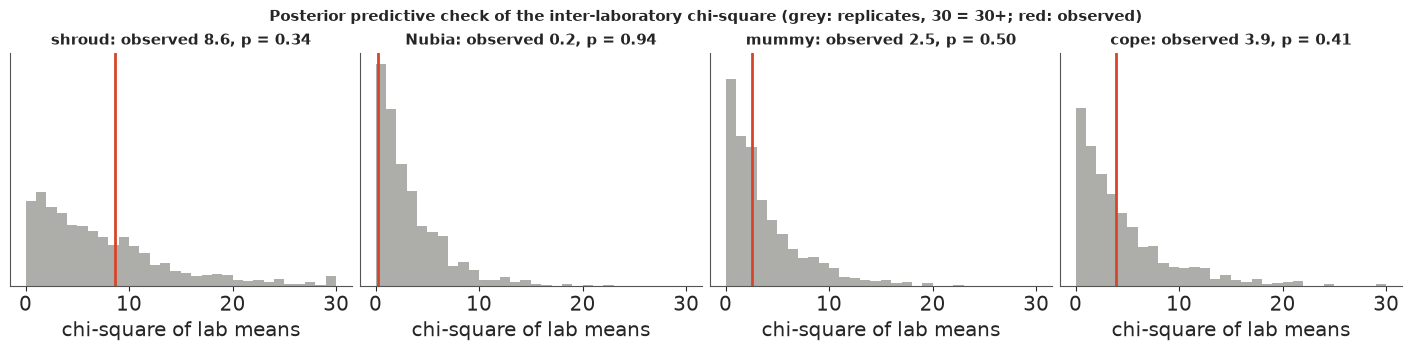

In [15]:
def grid_weights(rbar_draws, i):
    """Posterior probability of each calendar year for textile i, one row per draw."""
    v = 1 / W_I[i] + S_Y**2
    lg = LOG_PRIOR[i] - 0.5 * (rbar_draws[:, None] - MU_Y) ** 2 / v - 0.5 * np.log(v)
    lg -= lg.max(1, keepdims=True)
    p = np.exp(lg)
    return p / p.sum(1, keepdims=True)


thin = az.extract(lab_idata, num_samples=1000, random_seed=RANDOM_SEED)
delta_d = thin["delta"].to_numpy().T                           # draws x lab
eta_d = thin["eta"].transpose("sample", "textile", "lab").to_numpy()
rbar_d = thin["rbar"].to_numpy().T                             # draws x textile
n_d = len(rbar_d)
theta_d = np.zeros((n_d, 4), int)
year_post = np.zeros((4, len(YEAR)))
for i in range(4):
    P = grid_weights(rbar_d[:, i], i)
    year_post[i] = P.mean(0)
    theta_d[:, i] = YEAR[(P.cumsum(1) < rng.uniform(size=(n_d, 1))).sum(1)]
year_idx_d = theta_d - YEAR[0]
c_rep = rng.normal(MU_Y[year_idx_d], S_Y[year_idx_d])
y_rep = (c_rep[:, smp_i] + delta_d[:, lab_i] + eta_d[:, smp_i, lab_i] + rng.normal(0, 1, (n_d, len(d))) * sd_obs)
T_rep = np.array([ward_wilson_T(*lab_means(yr, sd_obs, smp_i, lab_i)) for yr in y_rep])
ppp = (T_rep >= T_obs).mean(0)

print("posterior predictive P(replicated chi-square >= observed):", dict(zip(TEXTILES, ppp.round(2))))
print("classical p-values if the quoted errors were the whole story (chi-square, 2 df):",
      dict(zip(TEXTILES, np.exp(-T_obs / 2).round(3))))
fig, axes = plt.subplots(1, 4, figsize=(14, 3.4), sharey=True)
for i, ax in enumerate(axes):
    ax.hist(np.clip(T_rep[:, i], 0, 30), bins=np.arange(0, 30.5, 1), color=GREY, alpha=0.7, density=True)
    ax.axvline(T_obs[i], color=CAL, lw=2)
    ax.set_title(f"{TEXTILES[i]}: observed {T_obs[i]:.1f}, p = {ppp[i]:.2f}", fontsize=11)
    ax.set(xlabel="chi-square of lab means", yticks=[])
fig.suptitle("Posterior predictive check of the inter-laboratory chi-square (grey: replicates, 30 = 30+; "
             "red: observed)", fontsize=11);

With the heterogeneity terms in the model, the observed chi-squares are typical of what the
model generates for every textile, the shroud included: the model has *explained* the
disagreement rather than ignored it. (A model that trusted the quoted errors, $\tau = 0$,
gives the shroud's chi-square a p-value of about 1% with these errors, 4% with the paper's -
which is where the 1989 debate
started - the second line above; the chi-square of 2 d.f. has the closed-form p-value
$e^{-T/2}$.)

> **In plain words:** The three labs disagree a bit more about the shroud than about the
> control cloths. Our model lets each lab have its own small bias and lets the shroud pieces
> differ from each other, and then asks what date is consistent with all of it.

## 6 · The calendar date of the shroud

For every posterior draw the grid gives the exact conditional distribution of each textile's
calendar year; averaging those over draws gives the marginal posterior (and one sampled year
per draw gives draws of $\theta$ for anything else). First the controls, as a check.

In [16]:
def summarise_year(p, year=YEAR):
    c = np.cumsum(p)
    q = [int(year[np.searchsorted(c, v)]) for v in (0.025, 0.5, 0.975)]
    return {"median": ad_label(q[1]), "95% equal-tailed": f"{ad_label(q[0])} to {ad_label(q[2])}",
            "95% HPD": fmt_ranges(hpd_ranges(p, year))}


pd.DataFrame({t: summarise_year(year_post[i]) | {"prior window": f"{ad_label(WINDOWS[t][0])} to {ad_label(WINDOWS[t][1])}"}
              for i, t in enumerate(TEXTILES)}).T

,median,95% equal-tailed,95% HPD,prior window
shroud,AD 1314,AD 1278 to AD 1389,"AD 1273-1326, AD 1353-1394",1001 BC to AD 1900
Nubia,AD 1105,AD 1043 to AD 1195,"AD 1040-1109, AD 1114-1179, AD 1189-1200",AD 1001 to AD 1200
mummy,AD 64,26 BC to AD 151,"37 BC-13 BC, AD 4-127",301 BC to AD 200
cope,AD 1293,AD 1290 to AD 1304,AD 1290-1301,AD 1290 to AD 1310


The controls land where history puts them, and the mummy linen, which had only a loose
prior, comes out in the 1st century BC to 2nd century AD, like the British Museum's own date.
The cope's posterior piles up at the early end of its window: the labs measured it a little
too old for 1290-1310, which is precisely the information that nudges the lab offsets up.

Now the shroud, compared with calibrating Damon et al.'s pooled 691 ± 31.

In [17]:
p_model = year_post[0]
prob = {
    "before AD 1260": (YEAR < 1260),
    "AD 1260-1390 (Damon et al.'s range)": (YEAR >= 1260) & (YEAR <= 1390),
    "after AD 1390": (YEAR > 1390),
    "before AD 1000": (YEAR < 1000),
    "before AD 400": (YEAR < 400),
}
pd.DataFrame({"hierarchical model": {k: p_model[m].sum() for k, m in prob.items()},
              "pooled 691 ± 31": {k: p_shroud_pooled[m].sum() for k, m in prob.items()}}).map(
    lambda v: f"{v:.4f}" if v >= 1e-4 else ("< 1e-4" if v > 0 else "0 (underflow)"))

,hierarchical model,pooled 691 ± 31
before AD 1260,0.0053,0.0029
AD 1260-1390 (Damon et al.'s range),0.9768,0.9938
after AD 1390,0.0179,0.0034
before AD 1000,< 1e-4,< 1e-4
before AD 400,0 (underflow),< 1e-4


hierarchical model: {'median': 'AD 1314', '95% equal-tailed': 'AD 1278 to AD 1389', '95% HPD': 'AD 1273-1326, AD 1353-1394'}
pooled date       : {'median': 'AD 1297', '95% equal-tailed': 'AD 1275 to AD 1385', '95% HPD': 'AD 1273-1317, AD 1360-1388'}


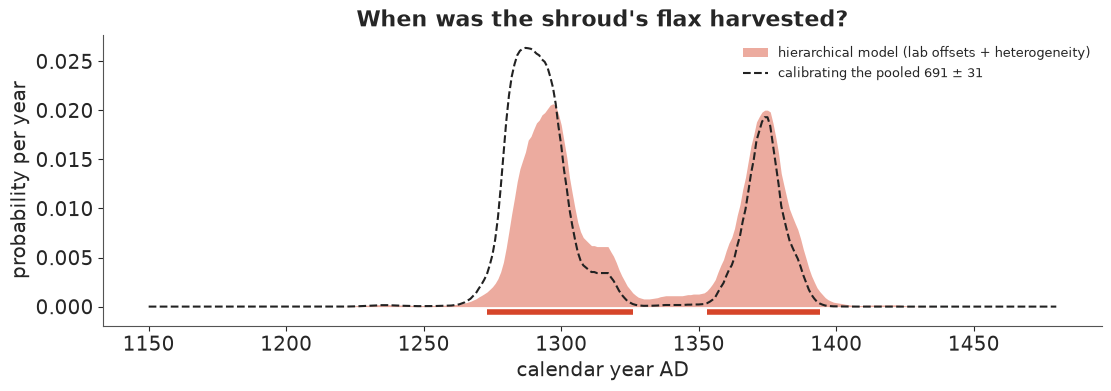

In [18]:
fig, ax = plt.subplots(figsize=(11, 3.8))
m = (YEAR >= 1150) & (YEAR <= 1480)
ax.fill_between(YEAR[m], 0, p_model[m], color=CAL, alpha=0.45, lw=0, label="hierarchical model (lab offsets + heterogeneity)")
ax.plot(YEAR[m], p_shroud_pooled[m], color=INK, lw=1.5, ls="--", label="calibrating the pooled 691 ± 31")
for (a, b), yv in zip(hpd_ranges(p_model), [-0.0006] * 5):
    ax.plot([a, b], [yv, yv], color=CAL, lw=4, solid_capstyle="butt")
ax.set(xlabel="calendar year AD", ylabel="probability per year", title="When was the shroud's flax harvested?")
ax.legend(fontsize=9)
print("hierarchical model:", summarise_year(p_model))
print("pooled date       :", summarise_year(p_shroud_pooled));

The hierarchical model moves the date slightly *later* than the pooled calibration (the labs'
shared tendency to read old, learned from the controls, is subtracted) and gives the two
bumps more equal weight; the chance of a date before 1260 stays well under 1%. The
first-century question has an unambiguous answer *within the model*: the probability is not
small but numerically zero, because a first-century linen should read about 1,950-2,000
radiocarbon years and the labs measured under 700, some forty standard errors away.

**So the real question is outside the model:** could something have made a first-century
cloth *look* medieval? The usual candidate is contamination with younger carbon. For each
posterior draw of the shroud's true radiocarbon content we can ask how much of the carbon
would have to be younger contamination for a cloth from AD 30 to read as it did. Radiocarbon
content is $F = e^{-\text{age}/8033}$ (the conventional Libby mean life), and a mixture with a
fraction $f$ of contaminant gives $F_{\text{meas}} = (1-f)F_{\text{true}} + f F_{\text{cont}}$.

In [19]:
def fraction_needed(age_meas, age_true, age_cont):
    F = lambda a: np.exp(-np.asarray(a, float) / 8033)
    return (F(age_meas) - F(age_true)) / (F(age_cont) - F(age_true))


age_ad30 = float(np.interp(1950 - 30, curve.cal_bp, curve.c14_bp))
c_shroud = rng.normal(rbar_d[:, 0], 1 / np.sqrt(W_I[0]))        # the shroud's true 14C age, per draw
age_1532 = float(np.interp(1950 - 1532, curve.cal_bp, curve.c14_bp))
contam = {"carbon from 1950 (the 'youngest' possible before bomb tests)": fraction_needed(c_shroud, age_ad30, 0.0),
          "carbon from the 1532 Chambéry fire": fraction_needed(c_shroud, age_ad30, age_1532)}
print(f"radiocarbon age of AD 30 on IntCal20: {age_ad30:.0f} BP; of AD 1532: {age_1532:.0f} BP")
print(f"shroud's true radiocarbon age (lab effects removed): median {np.median(c_shroud):.0f} BP, "
      f"90% {np.quantile(c_shroud, 0.05):.0f}-{np.quantile(c_shroud, 0.95):.0f}")
for k, f in contam.items():
    print(f"fraction of the carbon that must be contamination, {k}: median {np.median(f):.0%} "
          f"(90%: {np.quantile(f, 0.05):.0%}-{np.quantile(f, 0.95):.0%})")

radiocarbon age of AD 30 on IntCal20: 1971 BP; of AD 1532: 299 BP
shroud's true radiocarbon age (lab effects removed): median 661 BP, 90% 607-710
fraction of the carbon that must be contamination, carbon from 1950 (the 'youngest' possible before bomb tests): median 64% (90%: 61%-67%)
fraction of the carbon that must be contamination, carbon from the 1532 Chambéry fire: median 77% (90%: 73%-80%)


For a first-century cloth to give these readings, about **two thirds of its carbon** would
have to be twentieth-century contamination that survived three labs' different cleaning
methods, and about three quarters if the contamination came from the 1532 fire. That is the
scale of the claim a
first-century date requires. What the radiocarbon data cannot rule out is that the strip was
not representative of the cloth (the "medieval repair" hypothesis): that is a question about
the sample, not the measurement, and no statistical model of these 49 numbers can answer it.

> **In plain words:** The labs' readings, adjusted for each lab's small quirks, point to
> the late 1200s or the 1300s, with well under a 1-in-100 chance of anything before 1260. For
> the cloth to be from Jesus's time, well over half of the carbon in the tested strip would
> have to be modern dirt that three different cleaning methods all missed.

## 7 · A Bayesian chronology: Sluggan Bog

A single date is often vague; a *sequence* of dates can be sharp, because the order of the
layers is information. Our example is the peat core from **Sluggan Bog**, Co. Antrim,
Northern Ireland, studied for its pollen record by Smith & Goddard (1991, *New Phytologist*
118) and used as a test case for Bayesian age-depth modelling in the R package Bchron (Haslett
& Parnell 2008). 31 radiocarbon dates on bulk peat slices, from 44.5 cm to 518 cm depth.
Several dates come from the **same slice** (the same depth, 2-5 cm thick). The file is an R
data file; as in E23/E24 we read R's serialisation format directly.

In [20]:
def read_rdata(path):
    """Minimal reader for R's XDR serialisation (gzip, bzip2 or xz): named lists, vectors, strings."""
    raw = Path(path).read_bytes()
    buf = (bz2.decompress(raw) if raw[:2] == b"BZ" else
           lzma.decompress(raw) if raw[:6] == b"\xfd7zXZ\x00" else gzip.decompress(raw))
    assert buf[:7] in (b"RDX2\nX\n", b"RDX3\nX\n"), "not an XDR R data file"
    pos, refs = 7, []

    def i32():
        nonlocal pos
        pos += 4
        return struct.unpack(">i", buf[pos - 4:pos])[0]

    def item():
        nonlocal pos
        flags = i32()
        kind, has_attr, has_tag = flags & 0xFF, flags & (1 << 9), flags & (1 << 10)
        if kind == 254:                                     # NULL
            return None
        if kind == 255:                                     # reference to an earlier symbol
            return refs[(flags >> 8) - 1]
        if kind == 1:                                       # symbol
            refs.append(item())
            return refs[-1]
        if kind == 9:                                       # string
            n = i32()
            pos += max(n, 0)
            return None if n == -1 else buf[pos - n:pos].decode()
        if kind == 2:                                       # pairlist -> dict
            out = {}
            while kind == 2:
                _ = item() if has_attr else None
                tag = item() if has_tag else None
                out[tag] = item()
                flags = i32()
                kind, has_attr, has_tag = flags & 0xFF, flags & (1 << 9), flags & (1 << 10)
            return out
        n = i32()
        if kind in (10, 13):                                # logical / integer
            value, pos = np.frombuffer(buf, ">i4", n, pos).astype(int), pos + 4 * n
        elif kind == 14:                                    # double
            value, pos = np.frombuffer(buf, ">f8", n, pos).astype(float), pos + 8 * n
        elif kind in (16, 19):                              # character vector / list
            value = [item() for _ in range(n)]
        else:
            raise NotImplementedError(f"R type {kind}")
        attrs = item() if has_attr else None
        if kind == 19 and attrs and "names" in attrs:
            value = dict(zip(attrs["names"], value))
        return value

    version = i32()
    pos += 8
    if version == 3:
        pos += 4 + struct.unpack(">i", buf[pos:pos + 4])[0]
    return item()


data.describe("sluggan_moss")
bog = pd.DataFrame(read_rdata(data.path("sluggan_moss"))["Sluggan"])
bog = bog.drop(columns="calCurves").sort_values(["position", "ages"]).reset_index(drop=True)
DEPTHS = np.sort(bog.position.unique())
K = len(DEPTHS)
lev = np.searchsorted(DEPTHS, bog.position.to_numpy())
print(f"{len(bog)} dates at {K} depths; slices with several dates: "
      f"{ {float(x): int(n) for x, n in bog.position.value_counts().items() if n > 1} }")
bog.T

sluggan_moss: R data file (bzip2-compressed XDR): a data frame of 31 radiocarbon dates down a peat core: id, ages (14C yr BP), ageSds, position (depth in cm), thickness (cm), calCurves. Several dates share a depth.
  source: Smith & Goddard (1991), A 12,500 year record of vegetational history at Sluggan Bog, Co. Antrim, N. Ireland, New Phytologist 118:167-187; as distributed in the R package Bchron (Haslett & Parnell 2008), from the European Pollen Database.
  url:    https://raw.githubusercontent.com/cran/Bchron/master/data/Sluggan.rda
31 dates at 21 depths; slices with several dates: {232.5: 3, 272.5: 3, 367.5: 3, 447.5: 3, 484.5: 2, 518.0: 2}


,0,1,2,3,4,5,6,7,8,9,...,21,22,23,24,25,26,27,28,29,30
id,1.0,2.0,20.0,30.0,21.0,22.0,23.0,5.0,4.0,3.0,...,13.0,14.0,15.0,27.0,16.0,17.0,28.0,29.0,18.0,19.0
ages,985.0,1225.0,1635.0,2130.0,2930.0,3945.0,4180.0,4500.0,4520.0,4650.0,...,8895.0,9130.0,9475.0,9610.0,10805.0,10945.0,10995.0,11625.0,12060.0,12470.0
ageSds,45.0,65.0,75.0,45.0,85.0,85.0,90.0,80.0,75.0,75.0,...,125.0,135.0,145.0,130.0,125.0,145.0,160.0,160.0,125.0,125.0
position,44.5,49.5,69.0,102.0,125.0,165.0,185.0,232.5,232.5,232.5,...,447.5,447.5,447.5,461.0,484.5,484.5,499.0,509.0,518.0,518.0
thickness,5.0,5.0,2.0,4.0,2.0,2.0,2.0,5.0,5.0,5.0,...,5.0,5.0,5.0,2.0,5.0,5.0,2.0,2.0,4.0,4.0


**Calibrating each date on its own** (the same grid calculation, now in cal BP over 0-20,000
years at 5-year steps), and plotting against depth:

,position,ages,ageSds,indep_lo,indep_med,indep_hi
18,367.5,8360,60,9153.0,9368.0,9497.0
19,407.0,8540,120,9228.0,9530.0,9895.0
20,427.0,9360,150,10255.0,10597.0,11098.0
21,447.5,8895,125,9593.0,9968.0,10243.0
22,447.5,9130,135,9876.0,10315.0,10642.0
23,447.5,9475,145,10337.0,10774.0,11166.0
24,461.0,9610,130,10584.0,10937.0,11230.0


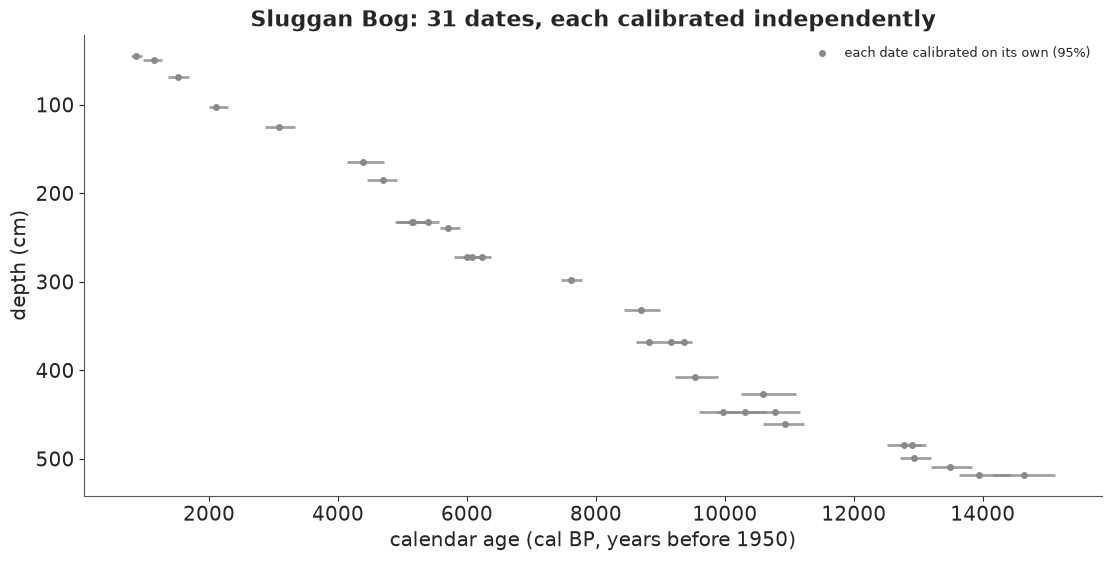

In [21]:
TOP, STEP = 20000.0, 5.0
BP = np.arange(0, TOP + 1, STEP)
MU_B = np.interp(BP, curve.cal_bp, curve.c14_bp)
S_B = np.interp(BP, curve.cal_bp, curve.c14_sd)
y_bog, e_bog = bog.ages.to_numpy(float), bog.ageSds.to_numpy(float)
V_B = e_bog[:, None] ** 2 + S_B**2
LIK_B = np.exp(-0.5 * (y_bog[:, None] - MU_B) ** 2 / V_B) / np.sqrt(2 * np.pi * V_B)  # density in y, per cal year
# cumulative integral over calendar years, scaled so each date's total is 1
CUM = np.concatenate([np.zeros((len(bog), 1)), np.cumsum((LIK_B[:, 1:] + LIK_B[:, :-1]) / 2 * STEP, axis=1)], axis=1)
CUM /= CUM[:, -1:]
indep_q = np.array([[np.interp(q, c, BP) for q in (0.025, 0.5, 0.975)] for c in CUM])
bog["indep_lo"], bog["indep_med"], bog["indep_hi"] = indep_q.T.round()


def depth_plot(ax, lo, med, hi, color, label, offset=0.0, lw=2):
    ax.plot(med, bog.position + offset, "o", color=color, ms=4, label=label)
    ax.hlines(bog.position + offset, lo, hi, color=color, lw=lw, alpha=0.8)


fig, ax = plt.subplots(figsize=(11, 5.5))
depth_plot(ax, *indep_q.T, GREY, "each date calibrated on its own (95%)")
ax.invert_yaxis()
ax.set(xlabel="calendar age (cal BP, years before 1950)", ylabel="depth (cm)",
       title="Sluggan Bog: 31 dates, each calibrated independently")
ax.legend(fontsize=9);
bog[["position", "ages", "ageSds", "indep_lo", "indep_med", "indep_hi"]].iloc[18:25]

Mostly the dates get older with depth, as they must - but not everywhere. The slice at 427 cm
(9360 ± 150 BP) calibrates to about 10,600 cal BP, older than one of the three dates in the
slice 20 cm below it (8895 ± 125, about 9,970 cal BP). And the three dates in the 367.5 cm
slice span 8,830-9,370 cal BP between them. Bulk peat dates are notorious for this: roots
grow down into older peat, and old carbon washes in.

## 8 · A sequence of phases, with the dates integrated out

The OxCal-style model (Bronk Ramsey 2009) for a stratified sequence treats each slice as a
**phase** bounded by two **boundaries**: every date in slice $k$ lies somewhere between
boundary $B_{k-1}$ (the top of the slice) and $B_k$ (its bottom), uniformly, and the
boundaries are in depth order, $B_0 < B_1 < \dots < B_K$ in cal BP. Dates within one slice are
*not* ordered among themselves. $B_0$ is the **end** of the record (the top of the dated peat)
and $B_K$ its **start**.

**Priors.** end $\sim U(0, 20000)$ and span $= B_K - B_0 \sim U(0, 20000)$ cal BP, and the
21 slice durations are the span times $\text{Dirichlet}(1, \dots, 1)$ proportions. Dirichlet(1)
spacings are exactly the gaps of uniformly scattered boundaries *given the span*, so this is
the uniform-phase prior - but because the span has its own prior, adding more boundaries does
not push the total span up (the known bias of putting independent uniform priors on many
ordered events; Nicholls & Jones 2001, *Applied Statistics*). This is the "ordered transform or
equivalent": `pm.Dirichlet` + `cumsum` gives ordered boundaries by construction.

**Integrating the dates out.** Given the boundaries, date $i$ in slice $k$ contributes

$$p(y_i \mid B) = \frac{1}{B_k - B_{k-1}} \int_{B_{k-1}}^{B_k} \mathcal N\bigl(y_i \mid \mu(\theta),\ \sigma_i^2 + s(\theta)^2\bigr)\, d\theta ,$$

a difference of the date's cumulative calibrated likelihood, precomputed once on the grid
(`CUM` above) and linearly interpolated at the boundaries. The integral is smooth in the
boundaries - it averages the wiggles away - so NUTS sees 23 well-behaved parameters and no
calendar dates at all. The dates are recovered afterwards by inverse-CDF sampling between
their boundaries.

**Outliers.** OxCal's answer to dates like the 427 cm one is an outlier model (Bronk Ramsey
2009, *Radiocarbon* 51:1023): each date is, with prior probability 5%, unrelated to its
slice. We make the outlier's calendar age uniform over the whole 0-20,000 range, so its
likelihood is $\int \mathcal N(y_i \mid \mu(\theta), \dots)\, d\theta / 20000$, and mix:
$p(y_i \mid B) = 0.95\, p_{\text{in}} + 0.05\, p_{\text{out}}$ (the indicator is summed out).
First, the model **without** outliers.

In [22]:
CUM_T = pt.as_tensor(CUM)
LOG_OUT = np.log(1 / TOP)      # every date's total (scaled) mass is 1, spread over 20,000 years
IDX = np.arange(len(bog))


def cum_at(b):
    """Each date's cumulative calibrated likelihood at the boundaries b (dates x boundaries)."""
    x = pt.clip(b / STEP, 0, len(BP) - 1.000001)
    i0 = pt.cast(pt.floor(x), "int64")
    f = x - i0
    return CUM_T[:, i0] * (1 - f) + CUM_T[:, i0 + 1] * f


def sequence_model(p_outlier):
    with pm.Model(coords={"slice": DEPTHS, "boundary_id": np.arange(K + 1), "date": IDX}) as model:
        end = pm.Uniform("end", 0.0, TOP)
        span = pm.Uniform("span", 0.0, TOP)
        gaps = pm.Dirichlet("gaps", np.ones(K), dims="slice")
        b = pm.Deterministic("boundary", end + span * pt.concatenate([pt.zeros(1), pt.cumsum(gaps)]),
                             dims="boundary_id")
        cb = cum_at(b)
        mass = cb[IDX, lev + 1] - cb[IDX, lev]
        ll_in = pt.log(pt.maximum(mass, 1e-300)) - pt.log(b[lev + 1] - b[lev])
        ll = ll_in if p_outlier == 0 else pt.logaddexp(np.log1p(-p_outlier) + ll_in, np.log(p_outlier) + LOG_OUT)
        pm.Deterministic("loglik_date", ll, dims="date")
        pm.Deterministic("loglik_in", ll_in, dims="date")
        pm.Potential("likelihood", ll.sum())
    return model


# start: boundaries between the independent medians of neighbouring slices, forced into order
slice_med = np.maximum.accumulate([np.median(indep_q[lev == k, 1]) for k in range(K)]) + np.arange(K)
b_init = np.r_[max(slice_med[0] - 100, 1.0), (slice_med[1:] + slice_med[:-1]) / 2, slice_med[-1] + 300]
INITVALS = {"end": b_init[0], "span": b_init[-1] - b_init[0], "gaps": np.diff(b_init) / (b_init[-1] - b_init[0])}


def per_chain(idata):
    return pd.DataFrame({"mean log density": idata.sample_stats["logp"].mean("draw").to_numpy().round(1),
                         "span (median)": idata.posterior["span"].median("draw").to_numpy().round(0),
                         "start (median)": idata.posterior["boundary"].isel(boundary_id=-1).median("draw").to_numpy().round(0)},
                        index=[f"chain {c}" for c in range(idata.posterior.sizes["chain"])])


def diagnose(idata, name):
    ss = idata.sample_stats
    print(f"{name}: divergences {int(ss['diverging'].sum())}, mean tree depth {float(ss['depth'].mean()):.1f} "
          f"(max 10), boundaries: max r_hat {float(az.rhat(idata)['boundary'].max()):.2f}, "
          f"min bulk ESS {float(az.ess(idata)['boundary'].min()):.0f}")
    return per_chain(idata)


strict_idata = pm.sample(model=sequence_model(0.0), random_seed=RANDOM_SEED, progressbar=False,
                         initvals=INITVALS, target_accept=0.9, tune=1500,
                         var_names=["end", "span", "gaps", "boundary"])
diagnose(strict_idata, "no outliers")

no outliers: divergences 8, mean tree depth 10.0 (max 10), boundaries: max r_hat 1.02, min bulk ESS 255


,mean log density,span (median),start (median)
chain 0,-246.4,13928.0,14641.0
chain 1,-246.0,13997.0,14641.0
chain 2,-247.1,14050.0,14651.0
chain 3,-246.3,13996.0,14630.0


All four chains agree (the per-chain log densities and start boundaries match, r_hat about
1.02), but with a few divergences and a mean tree depth at the maximum of 10. The strict model
also has a trap that this run happened to avoid: while developing the notebook, with other
seeds and a shorter warm-up, one chain in two runs out of three got **stranded** hundreds or
thousands of log-density units below the others. nutpie's random start (jitter on the
unconstrained scale) had put some date outside its slice, where its calibrated likelihood
underflows to zero; the log density is then flat (we floor it at $10^{-300}$) and no gradient
leads back. And the strict model must squeeze the conflicting 427 cm and 447.5 cm dates into
order however badly they fit, which is exactly what an outlier model is for.

Now with a 5% outlier prior, same sampler settings:

In [23]:
seq_model = sequence_model(0.05)
diag_idata = pm.sample(model=seq_model, random_seed=RANDOM_SEED, progressbar=False, initvals=INITVALS,
                       target_accept=0.9, tune=1500, var_names=["end", "span", "gaps", "boundary"])
diagnose(diag_idata, "outliers, diagonal mass matrix")

outliers, diagonal mass matrix: divergences 0, mean tree depth 10.0 (max 10), boundaries: max r_hat 1.25, min bulk ESS 12


,mean log density,span (median),start (median)
chain 0,-247.8,13886.0,14556.0
chain 1,-247.8,13928.0,14608.0
chain 2,-248.5,14371.0,14749.0
chain 3,-247.8,13971.0,14635.0


Worse, not better: one chain disagrees with the others about the span and the start, r_hat
climbs to about 1.25 and the smallest ESS is around a dozen, without a single divergence.

The tell-tale sign is the **tree depth**: nearly every iteration hits the maximum of 10
(1,023 leapfrog steps). The posterior is long and thin in directions that mix many
parameters - move one interior boundary and its neighbours, the span and the Dirichlet
proportions all have to move together - and a diagonal mass matrix cannot rescale a
diagonal ridge. nutpie's **low-rank mass-matrix adaptation** (`adaptation="low_rank"`)
learns the few dominant correlated directions during warm-up:

In [24]:
seq_idata = pm.sample(model=seq_model, random_seed=RANDOM_SEED, progressbar=False, initvals=INITVALS,
                      target_accept=0.9, tune=1500, nuts={"adaptation": "low_rank"})
del diag_idata
display(diagnose(seq_idata, "outliers, low-rank mass matrix"))
az.summary(seq_idata, var_names=["end", "span"], round_to=0)

outliers, low-rank mass matrix: divergences 1, mean tree depth 9.2 (max 10), boundaries: max r_hat 1.01, min bulk ESS 468


,mean log density,span (median),start (median)
chain 0,-248.1,13937.0,14614.0
chain 1,-248.1,13937.0,14577.0
chain 2,-247.8,13986.0,14628.0
chain 3,-248.4,13989.0,14663.0


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
end,669.0,216.0,240.0,909.0,468.0,379.0,1.0,11.0,12.0
span,14047.0,514.0,13403.0,14916.0,1069.0,1396.0,1.0,17.0,21.0


Every chain now agrees, r_hat is at most about 1.01 and the smallest bulk ESS over the 22
boundaries is in the hundreds, at a similar run time. The outlier component does two jobs:
statistically it lets a conflicting date be discounted, and computationally it puts a floor
under every date's likelihood ($0.05 / 20000$ per year), so there are no flat zero-likelihood
plateaus to get stranded on.

**Which dates are outliers?** The posterior probability that date $i$ is an outlier, averaged
over draws, is $0.05\,p_{\text{out}} / (0.05\,p_{\text{out}} + 0.95\,p_{\text{in}})$.

In [25]:
post_seq = az.extract(seq_idata)
ll_in_d = post_seq["loglik_in"].to_numpy().T                    # draws x dates
log_in = np.log(0.95) + ll_in_d
log_out = np.log(0.05) + LOG_OUT
p_out_d = 1 / (1 + np.exp(log_in - log_out))
bog["p_outlier"] = p_out_d.mean(0).round(3)
print("prior outlier probability 0.05; the six highest posterior values:")
bog.sort_values("p_outlier", ascending=False).head(6)[["position", "ages", "ageSds", "indep_med", "p_outlier"]]

prior outlier probability 0.05; the six highest posterior values:


,position,ages,ageSds,indep_med,p_outlier
20,427.0,9360,150,10597.0,0.102
21,447.5,8895,125,9968.0,0.095
30,518.0,12470,125,14642.0,0.015
16,367.5,7975,70,8830.0,0.013
14,297.5,6760,90,7615.0,0.008
24,461.0,9610,130,10937.0,0.007


The two dates with the highest outlier probability are exactly the conflicting pair: 9360 BP
at 427 cm and 8895 BP in the slice below it. But the model does not throw either out: their
probability only doubles from the 5% prior to about 10%, and every other date stays at or
below the prior. The conflict is mild enough (the 447.5 cm slice can stretch, and the
calibrated ranges overlap a little) that keeping both dates in their slices is the better
explanation. The sequence results below barely differ from the strict model's (compare the
start boundaries in the two per-chain tables). Because the outlier indicator is summed out,
none of this cost anything in sampling.

**Recovering every date.** For each posterior draw we draw the outlier indicator from its
conditional probability, then the calendar age: from the date's calibration restricted to
its slice (inverse CDF between the two boundaries), or from its unrestricted calibration if
it is an outlier.

95% interval width, independent / sequence: median ratio 1.05 (range 0.87 to 1.49)


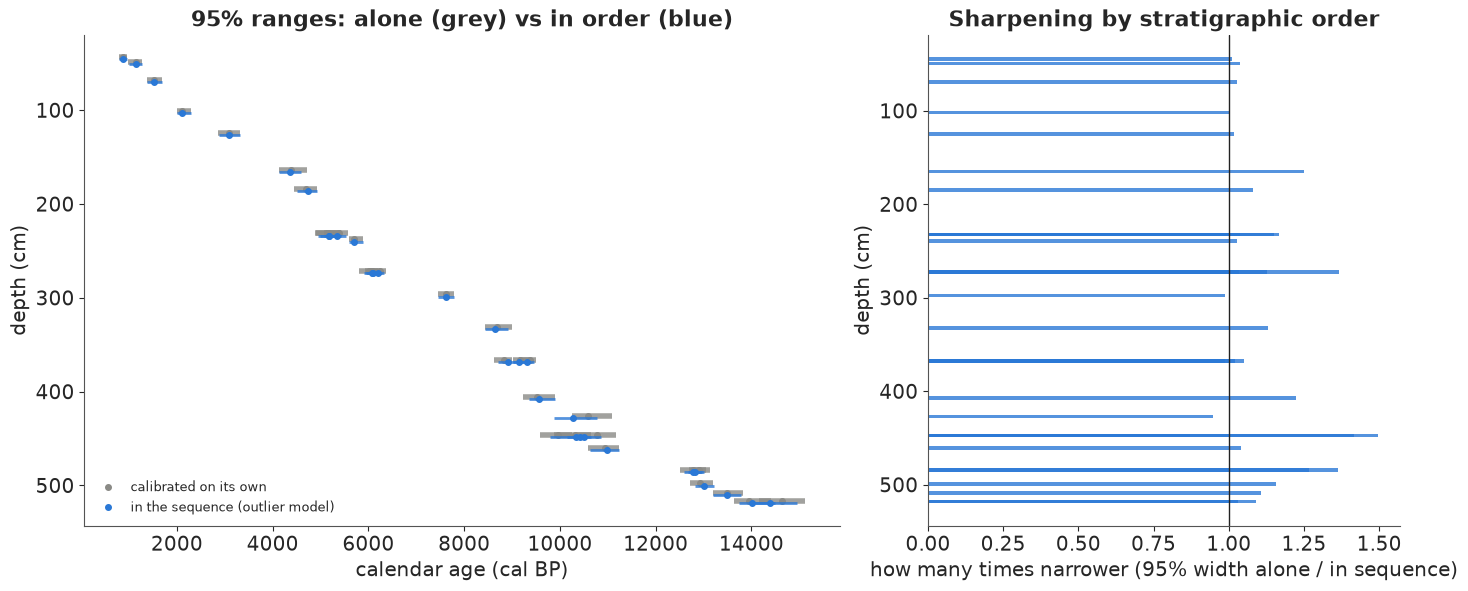

In [26]:
bnd = post_seq["boundary"].to_numpy().T                          # draws x (K+1)
n_draws = len(bnd)
is_out = rng.uniform(size=p_out_d.shape) < p_out_d
theta_seq = np.empty((n_draws, len(bog)))
for i in range(len(bog)):
    lo_c = np.interp(bnd[:, lev[i]], BP, CUM[i])
    hi_c = np.interp(bnd[:, lev[i] + 1], BP, CUM[i])
    u = np.where(is_out[:, i], rng.uniform(size=n_draws), lo_c + (hi_c - lo_c) * rng.uniform(size=n_draws))
    theta_seq[:, i] = np.interp(u, CUM[i], BP)
seq_q = np.quantile(theta_seq, [0.025, 0.5, 0.975], axis=0)
width_ratio = (indep_q[:, 2] - indep_q[:, 0]) / (seq_q[2] - seq_q[0])
print(f"95% interval width, independent / sequence: median ratio {np.median(width_ratio):.2f} "
      f"(range {width_ratio.min():.2f} to {width_ratio.max():.2f})")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.8), gridspec_kw={"width_ratios": [1.6, 1]})
ax = axes[0]
depth_plot(ax, *indep_q.T, GREY, "calibrated on its own", offset=-1.2, lw=4)
depth_plot(ax, *seq_q, SEQ, "in the sequence (outlier model)", offset=1.2)
b_q = np.quantile(bnd, [0.025, 0.5, 0.975], axis=0)
ax.set(xlabel="calendar age (cal BP)", ylabel="depth (cm)", title="95% ranges: alone (grey) vs in order (blue)")
ax.invert_yaxis()
ax.legend(fontsize=9, loc="lower left")
ax = axes[1]
ax.barh(bog.position, width_ratio, height=4, color=SEQ, alpha=0.8)
ax.axvline(1, color=INK, lw=1)
ax.invert_yaxis()
ax.set(xlabel="how many times narrower (95% width alone / in sequence)", ylabel="depth (cm)",
       title="Sharpening by stratigraphic order");

Here order helps only modestly: the typical date's 95% range is about 5% narrower, and the
best case about a third narrower. That is a property of this core, not of the method: its
dates are mostly a thousand years apart, far more than their calibrated widths, so the
neighbours rarely cut into each other's ranges. The gains are where neighbours overlap - the
447.5 cm slice under the 427 cm date, the 272.5 cm and 484.5 cm slices - and a date whose
neighbours all lie far away gains nothing. A few dates come out slightly *wider* than alone
(ratio below 1): the outlier branch keeps a little of their whole calibration in play.
Sequences of closely spaced dates, such as a site occupied for a few generations, sharpen
far more; that is where OxCal models earn their reputation.

### Boundaries and durations

The boundaries are the chronology's headline quantities: when did peat start to accumulate
at the base of the core, when does the dated record end, and how long did individual slices
take to form?

In [27]:
start_d, end_d = bnd[:, -1], bnd[:, 0]
k367 = int(np.flatnonzero(DEPTHS == 367.5)[0])
slice_dur = bnd[:, 1:] - bnd[:, :-1]
rows = {
    "start of the record (base, below 518 cm)": start_d,
    "end of the dated record (top, above 44.5 cm)": end_d,
    "total duration": start_d - end_d,
    "duration of the 367.5 cm slice (5 cm, 3 dates)": slice_dur[:, k367],
    "duration of the 232.5 cm slice (5 cm, 3 dates)": slice_dur[:, int(np.flatnonzero(DEPTHS == 232.5)[0])],
}
pd.DataFrame({k: {"median": f"{np.median(v):,.0f}", "95% range": f"{np.quantile(v, 0.025):,.0f} to {np.quantile(v, 0.975):,.0f}"}
              for k, v in rows.items()}).T

,median,95% range
"start of the record (base, below 518 cm)","14,624","14,119 to 15,797"
"end of the dated record (top, above 44.5 cm)",734,111 to 926
total duration,"13,966","13,315 to 15,227"
"duration of the 367.5 cm slice (5 cm, 3 dates)",640,"263 to 1,031"
"duration of the 232.5 cm slice (5 cm, 3 dates)",499,"22 to 1,006"


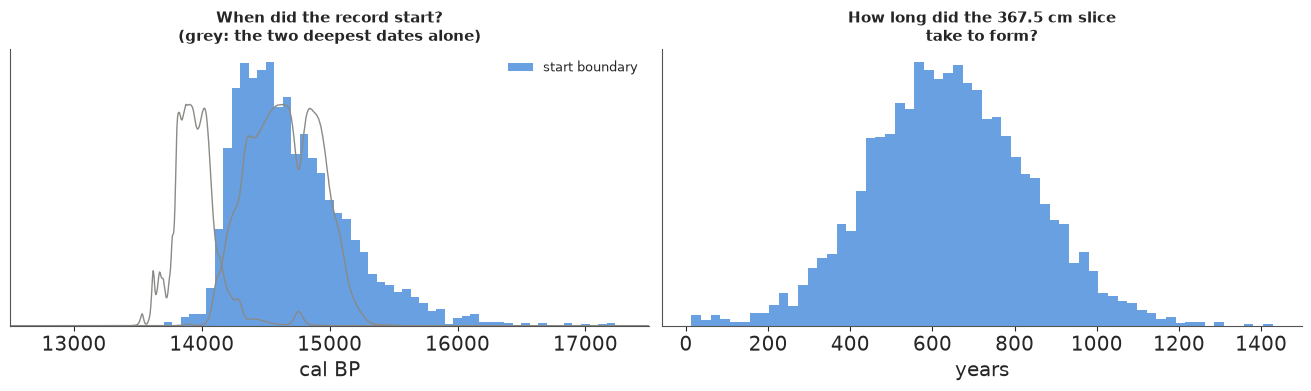

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
ax = axes[0]
ax.hist(start_d, bins=60, color=SEQ, alpha=0.7, density=True, label="start boundary")
i_bot = np.flatnonzero(bog.position == DEPTHS[-1])
for i in i_bot:
    ax.plot(BP, LIK_B[i] / LIK_B[i].max() * 0.8 * ax.get_ylim()[1], color=GREY, lw=1)
ax.set(xlim=(12500, 17500), xlabel="cal BP", yticks=[])
ax.set_title("When did the record start?\n(grey: the two deepest dates alone)", fontsize=11)
ax.legend(fontsize=9)
ax = axes[1]
ax.hist(slice_dur[:, k367], bins=60, color=SEQ, alpha=0.7, density=True)
ax.set(xlabel="years", yticks=[])
ax.set_title("How long did the 367.5 cm slice\ntake to form?", fontsize=11);

The start boundary sits just older than the older of the two dates from the base (12470 BP,
about 14,600 cal BP), with a tail beyond 15,500: nothing below 518 cm is dated, so the data
bound it from one side only, and the prior on the span decides how far it may stretch. The
end of the dated record is younger than the top date (about 860 cal BP), by an amount the
data barely constrain. Slice durations are the model's weakest output: the 367.5 cm slice,
whose three dates disagree, needs a few hundred years to hold them, but even the 232.5 cm
slice, whose three dates agree closely, is given anything from a few decades to a thousand
years. The model knows only the *order* of the slices, not their depths, so a slice may
stretch to fill the gap to its neighbours. At the core's average accumulation rate (474 cm
in about 14,000 years) a 5 cm slice represents about 150 years; age-depth models such as
Bchron and Bacon add exactly this depth information.

> **In plain words:** Taken one at a time, a date from the bog can be vague. Knowing that
> deeper peat must be older pins each date between its neighbours - here only a little,
> because the dated layers are far apart in time. The bog's record begins roughly 14,500 to
> 15,500 years ago.

**Age-depth curve.** The same draws give the classic age-depth plot: for each depth, the
band of plausible ages.

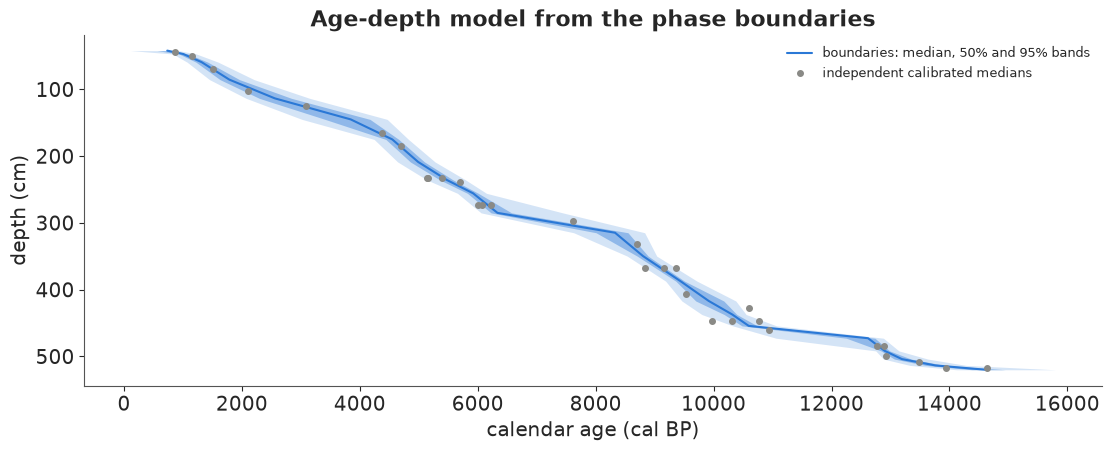

In [29]:
fig, ax = plt.subplots(figsize=(11, 4.4))
mid_depth = np.r_[DEPTHS[0] - 2.5, (DEPTHS[1:] + DEPTHS[:-1]) / 2, DEPTHS[-1] + 2]  # boundary depths (slice edges)
for lo_q, hi_q, a in [(0.025, 0.975, 0.2), (0.25, 0.75, 0.4)]:
    ax.fill_betweenx(mid_depth, np.quantile(bnd, lo_q, axis=0), np.quantile(bnd, hi_q, axis=0), color=SEQ, alpha=a, lw=0)
ax.plot(np.median(bnd, axis=0), mid_depth, color=SEQ, lw=1.5, label="boundaries: median, 50% and 95% bands")
ax.plot(indep_q[:, 1], bog.position, "o", color=GREY, ms=4, label="independent calibrated medians")
ax.invert_yaxis()
ax.set(xlabel="calendar age (cal BP)", ylabel="depth (cm)", title="Age-depth model from the phase boundaries")
ax.legend(fontsize=9);

(Boundary depths are placed half-way between dated slices for plotting; the model itself
only knows the order.)

## 9 · Explaining it to everyone

Four displays for someone who has never heard of a calibration curve, each built from the
posterior above. No Greek, no "HDI": "likely range", "equally likely answers", counts.

### 9.1 "How a lab number becomes a date": the shadow

The laboratory reports a number on one scale; history lives on another. A single picture of
the translation, with the lab result as a lamp shining through the conversion curve.

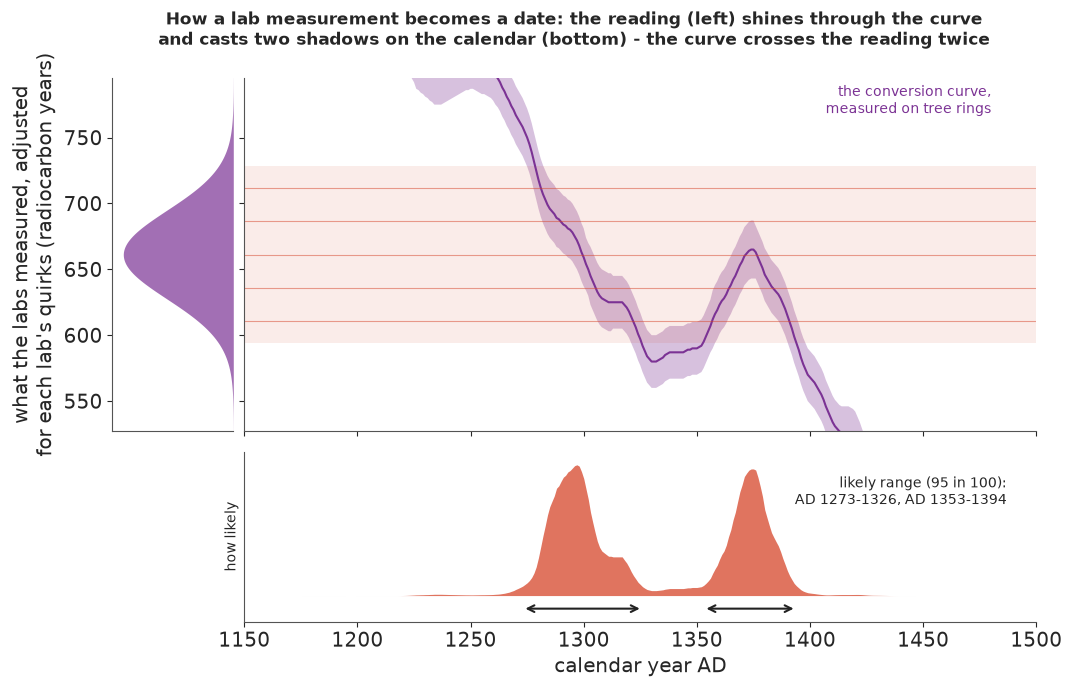

In [30]:
fig = plt.figure(figsize=(11, 6.8), layout="none")
ax_main = fig.add_axes([0.2, 0.36, 0.72, 0.52])
ax_left = fig.add_axes([0.08, 0.36, 0.11, 0.52])
ax_bot = fig.add_axes([0.2, 0.08, 0.72, 0.25])
xl = (1150, 1500)
m = (YEAR >= xl[0]) & (YEAR <= xl[1])
lab_c = np.median(c_shroud)
lab_sd = np.std(c_shroud)
ax_main.fill_between(YEAR[m], MU_Y[m] - 2 * S_Y[m], MU_Y[m] + 2 * S_Y[m], color=C14, alpha=0.3, lw=0)
ax_main.plot(YEAR[m], MU_Y[m], color=C14, lw=1.5)
yy = np.linspace(lab_c - 4 * lab_sd, lab_c + 4 * lab_sd, 200)
dens_lab = np.exp(-0.5 * ((yy - lab_c) / lab_sd) ** 2)
ax_left.fill_betweenx(yy, 0, dens_lab, color=C14, alpha=0.7, lw=0)
for k in (-1.5, -0.75, 0, 0.75, 1.5):                   # a few "light rays" from the reading
    ax_main.axhline(lab_c + k * lab_sd, color=CAL, lw=0.8, alpha=0.5)
ax_main.axhspan(lab_c - 2 * lab_sd, lab_c + 2 * lab_sd, color=CAL, alpha=0.1, lw=0)
ax_main.set(xlim=xl, ylim=(yy[0], yy[-1]))
ax_main.tick_params(labelbottom=False, labelleft=False)
ax_main.text(1480, lab_c + 3.2 * lab_sd, "the conversion curve,\nmeasured on tree rings", color=C14, ha="right", fontsize=10)
ax_left.set(xlim=(1.1, 0), ylim=(yy[0], yy[-1]), xticks=[], ylabel="what the labs measured, adjusted\nfor each lab's quirks (radiocarbon years)")
ax_bot.fill_between(YEAR[m], 0, p_model[m], color=CAL, alpha=0.75, lw=0)
ax_bot.set(xlim=xl, yticks=[], xlabel="calendar year AD")
ax_bot.set_ylabel("how likely", fontsize=10)
for (a, b) in hpd_ranges(p_model, prob=0.95):
    ax_bot.annotate("", xy=(a, -p_model.max() * 0.1), xytext=(b, -p_model.max() * 0.1),
                    arrowprops=dict(arrowstyle="<->", color=INK, lw=1.5), annotation_clip=False)
ax_bot.set_ylim(-p_model.max() * 0.2, p_model.max() * 1.1)
ax_bot.text(1487, p_model.max() * 0.7, f"likely range (95 in 100):\n{fmt_ranges(hpd_ranges(p_model))}",
            ha="right", fontsize=10)
fig.suptitle("How a lab measurement becomes a date: the reading (left) shines through the curve\n"
             "and casts two shadows on the calendar (bottom) - the curve crosses the reading twice", fontsize=12);

**Why it works:** it shows *why* the answer has two humps, which a table of ranges cannot,
and it makes the calibration curve a physical object (tree rings) rather than a formula.
**What it hides:** the lab offsets and heterogeneity (the purple bell is already the adjusted
reading), and the fact that the curve band itself is uncertain.

### 9.2 A timeline of history, with the shroud's "likely when" as a ribbon, and 20 equally likely dates

Put the answer on the scale people actually know - two thousand years of history - with the
events the shroud debate is about, and below it 20 dots, each an equally likely harvest year.

20 quantile dates: [1278 1285 1288 1291 1293 1296 1298 1300 1303 1308 1317 1341 1362 1367
 1370 1373 1375 1378 1382 1387]


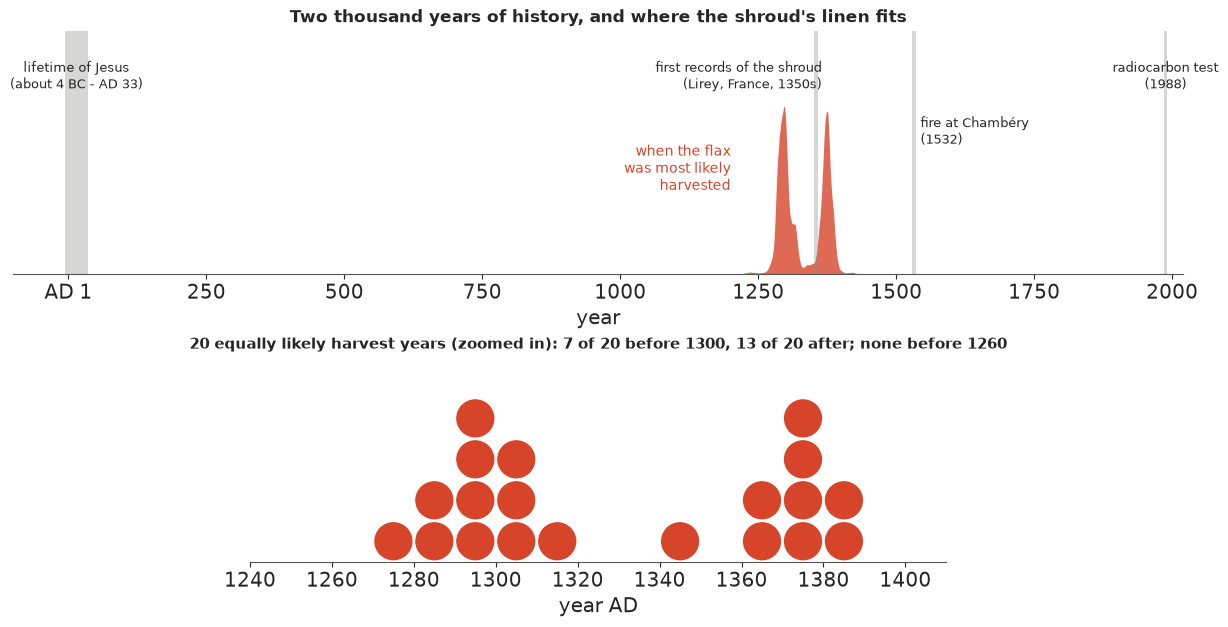

In [31]:
fig = plt.figure(figsize=(13, 6.4), layout="none")
ax = fig.add_axes([0.05, 0.52, 0.9, 0.38])
m = (YEAR >= -100) & (YEAR <= 2000)
ax.fill_between(YEAR[m], 0, p_model[m] / p_model.max(), color=CAL, alpha=0.8, lw=0)
events = [(-4, 33, "lifetime of Jesus\n(about 4 BC - AD 33)", 1.08, "center"),
          (1354, 1356, "first records of the shroud\n(Lirey, France, 1350s)", 1.08, "right"),
          (1532, 1532, "fire at Chambéry\n(1532)", 0.75, "left"), (1988, 1988, "radiocarbon test\n(1988)", 1.08, "center")]
for a, b, txt, yt, ha in events:
    ax.axvspan(a - 3, b + 3, color=GREY, alpha=0.35, lw=0)
    ax.text((a + b) / 2 + {"center": 0, "right": 10, "left": 12}[ha], yt, txt, ha=ha, va="bottom", fontsize=9)
ax.set(xlim=(-100, 2020), ylim=(0, 1.45), yticks=[], xlabel="year")
ax.set_xticks([0, 250, 500, 750, 1000, 1250, 1500, 1750, 2000], ["AD 1", "250", "500", "750", "1000", "1250", "1500", "1750", "2000"])
for s in ["left", "right", "top"]:
    ax.spines[s].set_visible(False)
ax.text(1200, 0.5, "when the flax\nwas most likely\nharvested", ha="right", color=CAL, fontsize=10)
ax.set_title("Two thousand years of history, and where the shroud's linen fits", fontsize=12)

ax2 = fig.add_axes([0.05, 0.07, 0.9, 0.32])
q20 = np.quantile(theta_d[:, 0], (np.arange(20) + 0.5) / 20)
edges = np.arange(1240, 1411, 10)
cols = np.clip(np.digitize(q20, edges) - 1, 0, len(edges) - 2)
heights = np.zeros(len(edges), int)
for c in cols:
    ax2.add_patch(Ellipse((edges[c] + 5, (heights[c] + 0.5) * 10), 9, 9, color=CAL))
    heights[c] += 1
ax2.set(xlim=(1240, 1410), ylim=(0, (heights.max() + 1) * 10), yticks=[], aspect="equal", xlabel="year AD")
for s in ["left", "right", "top"]:
    ax2.spines[s].set_visible(False)
n_before_1300 = int((q20 < 1300).sum())
ax2.set_title(f"20 equally likely harvest years (zoomed in): {n_before_1300} of 20 before 1300, "
              f"{20 - n_before_1300} of 20 after; none before 1260", fontsize=11)
print("20 quantile dates:", np.round(q20).astype(int))

**Why it works:** the ribbon on a two-thousand-year axis shows at a glance that the answer is
not "around Jesus's time, give or take" - the whole ribbon sits thirteen centuries later -
and that it runs up to the time the cloth first appears in the historical record. The dots
answer "how sure"
by counting. **What it hides:** the ribbon's height is scaled to its peak (only its shape
matters), and both panels are conditional on the sample being representative of the cloth.

### 9.3 "What would it take?": a frequency picture of the first-century claim

"Probability zero" invites disbelief. Instead, show what a first-century date would require:
out of 100 atoms of carbon in the tested strip, how many would have to be modern dirt?

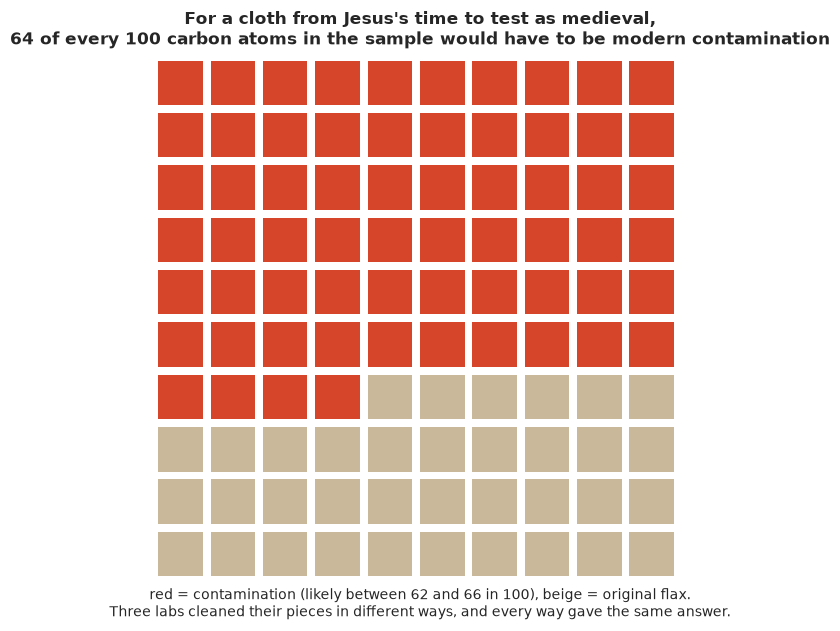

In [32]:
f_modern = contam["carbon from 1950 (the 'youngest' possible before bomb tests)"]
n_contam = int(round(100 * np.median(f_modern)))
lo80, hi80 = (int(round(100 * v)) for v in np.quantile(f_modern, [0.1, 0.9]))
fig, ax = plt.subplots(figsize=(7.5, 6.2))
for i in range(100):
    r_, c_ = divmod(i, 10)
    ax.add_patch(Rectangle((c_, 9 - r_), 0.85, 0.85, color=CAL if i < n_contam else "#c9b99a", lw=0))
ax.set(xlim=(0, 10), ylim=(-0.3, 10), xticks=[], yticks=[], aspect="equal")
for s in ax.spines.values():
    s.set_visible(False)
ax.set_title(f"For a cloth from Jesus's time to test as medieval,\n{n_contam} of every 100 carbon atoms "
             f"in the sample would have to be modern contamination", fontsize=12)
ax.text(5, -0.2, f"red = contamination (likely between {lo80} and {hi80} in 100), beige = original flax.\n"
        "Three labs cleaned their pieces in different ways, and every way gave the same answer.",
        ha="center", va="top", fontsize=10);

**Why it works:** it replaces an incomprehensible probability ("1 in $10^{300}$") with a
physical quantity people can judge for themselves - most of the sample would have to be
something else. It is also honest about where the real uncertainty lies: not in the
measurement, but in whether something outside the model happened. **What it hides:** it
assumes the most "efficient" contaminant (carbon from 1950); older contamination would need
even more (about three quarters for carbon from the 1532 fire).

### 9.4 Plausible histories of a bog (animation)

Press play. Each frame is one equally likely history of the lower half of Sluggan Bog
(320-520 cm, 8,000-15,500 years ago, where the dates crowd together): one plausible age for
every dated layer. On the left the layers are dated one at a time, and every one of these
histories zig-zags somewhere - a deeper layer younger than the one above it, which is
impossible. On the right the model keeps the layers in order.

In [33]:
n_frames = 36
fr_idx = rng.choice(n_draws, n_frames, replace=False)
indep_draws = np.array([[np.interp(rng.uniform(), CUM[i], BP) for i in range(len(bog))] for _ in range(n_frames)])
seq_draws = theta_seq[fr_idx]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), dpi=72, sharey=True)
lines = []
for ax, dr, (lo_b, hi_b), col, ttl in [
        (axes[0], indep_draws, (indep_q[:, 0], indep_q[:, 2]), GREY, "each layer dated on its own"),
        (axes[1], seq_draws, (seq_q[0], seq_q[2]), SEQ, "layers kept in order (deeper = older)")]:
    ax.fill_betweenx(bog.position, lo_b / 1000, hi_b / 1000, color=col, alpha=0.2, lw=0)  # likely range
    (ln,) = ax.plot(dr[0] / 1000, bog.position, "o-", color=col, ms=4, lw=1.2)
    ax.set(xlim=(8, 15.5), ylim=(525, 320), title=ttl, xlabel="thousand years ago")
    lines.append(ln)
axes[0].set_ylabel("depth in the bog (cm)")
count = fig.suptitle("", fontsize=12)


def n_out_of_order(dr):
    """Pairs of neighbouring slices where some date in the deeper slice is younger than one above it."""
    return np.array([sum(dr[k][lev == j + 1].min() < dr[k][lev == j].max() for j in range(K - 1) if DEPTHS[j] >= 320)
                     for k in range(len(dr))])


n_reversed = [n_out_of_order(dr) for dr in (indep_draws, seq_draws)]
plt.close(fig)


def update(i):
    lines[0].set_xdata(indep_draws[i] / 1000)
    lines[1].set_xdata(seq_draws[i] / 1000)
    count.set_text(f"Plausible history {i + 1} of {n_frames}: neighbouring layers out of order - "
                   f"left {n_reversed[0][i]}, right {n_reversed[1][i]}")
    return lines


anim = animation.FuncAnimation(fig, update, frames=n_frames, interval=600, blit=False)
print(f"neighbouring slices out of order (320-520 cm), per history: dated alone {np.mean(n_reversed[0]):.1f} on average, "
      f"at least one in {np.mean(n_reversed[0] > 0):.0%} of histories; in the sequence {np.mean(n_reversed[1]):.2f}")
HTML(anim.to_jshtml(default_mode="loop"))

neighbouring slices out of order (320-520 cm), per history: dated alone 2.1 on average, at least one in 100% of histories; in the sequence 0.25


**Why it works:** hypothetical-outcome animations show uncertainty as *movement*: the dots
jitter within their likely ranges, and the impossible zig-zags that keep appearing on the
left and not on the right make "order is information" something you see, with the count in
the title to confirm it. **What it hides:** a viewer sees one history at a time and must
watch several frames to sense the spread (the pale bands give it statically); the gain here
is modest, so the two panels look alike at a glance; and a date the model treats as an
outlier could still jump out of line on the right, which is honest but can look like a bug.

### 9.5 Export for a web page

A compact JSON of the lay-relevant results: the shroud's calendar distribution on a grid,
400 equally likely harvest years, the contamination fraction, the lab numbers, the bog's
dates alone vs in sequence and its boundaries, and a plain-English headline per quantity.

In [34]:
def r(x, nd=1):
    x = np.asarray(x, dtype=float)
    return [None if not np.isfinite(v) else round(float(v), nd) for v in x.ravel()]


gm = (YEAR >= 1150) & (YEAR <= 1500)
cm = (YEAR >= 1150) & (YEAR <= 1500) & (YEAR % 5 == 0)
i400 = rng.choice(n_d, 400, replace=False)
j400 = rng.choice(n_draws, 400, replace=False)
p_before_1260 = float(p_model[YEAR < 1260].sum())
export = {
    "id": "E39",
    "title": "How old is it? Radiocarbon dating the Shroud of Turin and a 15,000-year-old bog",
    "sources": {"curve": "IntCal20 (Reimer et al. 2020, Radiocarbon 62)",
                "shroud": "Damon et al. 1989, Nature 337: Table 1, 49 individual measurements",
                "bog": "Sluggan Bog, Smith & Goddard 1991, New Phytologist 118 (via R package Bchron)"},
    "units": {"year": "calendar year AD (astronomical: 0 = 1 BC)", "cal_bp": "calendar years before 1950",
              "c14_bp": "radiocarbon years before 1950"},
    "curve_segment": {"year": YEAR[cm].tolist(), "c14_mean": r(MU_Y[cm]), "c14_sd": r(S_Y[cm])},
    "shroud": {
        "measurements": d[["textile", "lab", "age_bp", "sd"]].query("textile == 'shroud'").to_dict("list"),
        "lab_means": {lab: {"mean": round(float(M_obs[0, j]), 1), "error": round(float(E_obs[0, j]), 1)} for j, lab in enumerate(LABS)},
        "adjusted_c14_age": {"median": round(float(np.median(c_shroud)), 1), "sd": round(float(np.std(c_shroud)), 1)},
        "calendar_density": {"year": YEAR[gm].tolist(), "model": r(p_model[gm], 6), "pooled_damon": r(p_shroud_pooled[gm], 6)},
        "year_draws": theta_d[i400, 0].tolist(),
        "likely_ranges_95": hpd_ranges(p_model),
        "probabilities": {k: round(float(p_model[msk].sum()), 5) for k, msk in prob.items()},
        "contamination_fraction_modern": {"quantiles": [0.1, 0.5, 0.9], "values": r(np.quantile(f_modern, [0.1, 0.5, 0.9]), 3)},
        "p_shroud_more_heterogeneous_than_controls": round(p_tau, 2),
    },
    "bog": {
        "depth_cm": bog.position.tolist(), "c14_age": bog.ages.tolist(), "c14_sd": bog.ageSds.tolist(),
        "quantiles": [0.025, 0.5, 0.975],
        "cal_bp_alone": [r(q, 0) for q in indep_q.T], "cal_bp_in_sequence": [r(q, 0) for q in seq_q],
        "p_outlier": r(bog.p_outlier, 2),
        "boundary_depth_cm": r(mid_depth, 1), "boundary_cal_bp_quantiles": [r(q, 0) for q in b_q],
        "start_cal_bp_draws": r(start_d[j400], 0), "end_cal_bp_draws": r(end_d[j400], 0),
        "width_ratio_median": round(float(np.median(width_ratio)), 2),
    },
}
export["headlines"] = {
    "shroud_date": f"The shroud's linen was most likely harvested in {fmt_ranges(hpd_ranges(p_model))} "
                   "(likely range, 95 in 100).",
    "shroud_before_1260": f"The chance it is older than 1260 is about {p_before_1260:.1%}; older than AD 400, effectively zero "
                          "- unless the tested strip was not representative of the cloth.",
    "contamination": f"For a first-century cloth to test like this, about {np.median(f_modern):.0%} of the carbon in the "
                     "sample would have to be modern contamination.",
    "bog_sharpening": f"Keeping the bog's layers in order makes a typical date's likely range only about "
                      f"{1 - 1 / np.median(width_ratio):.0%} narrower here (up to {1 - 1 / width_ratio.max():.0%}), "
                      "because the dated layers are mostly centuries apart.",
    "bog_start": f"Peat began to build up at Sluggan Bog about {np.median(start_d):,.0f} years before 1950 "
                 f"(likely range {np.quantile(start_d, 0.025):,.0f} to {np.quantile(start_d, 0.975):,.0f}).",
}
out = Path("../../.scratch/artifact/E39.json")
if not out.parent.exists():  # the build runs in notebooks/examples; fall back to the repo root
    out = Path(".scratch/artifact/E39.json")
out.parent.mkdir(parents=True, exist_ok=True)
out.write_text(json.dumps(export, ensure_ascii=False, separators=(",", ":")))
print(f"wrote {out} ({out.stat().st_size / 1024:.0f} KB)")
print(json.dumps(export["headlines"], indent=1, ensure_ascii=False))

wrote ../../.scratch/artifact/E39.json (20 KB)
{
 "shroud_date": "The shroud's linen was most likely harvested in AD 1273-1326, AD 1353-1394 (likely range, 95 in 100).",
 "shroud_before_1260": "The chance it is older than 1260 is about 0.5%; older than AD 400, effectively zero - unless the tested strip was not representative of the cloth.",
 "contamination": "For a first-century cloth to test like this, about 64% of the carbon in the sample would have to be modern contamination.",
 "bog_sharpening": "Keeping the bog's layers in order makes a typical date's likely range only about 5% narrower here (up to 33%), because the dated layers are mostly centuries apart.",
 "bog_start": "Peat began to build up at Sluggan Bog about 14,624 years before 1950 (likely range 14,119 to 15,797)."
}


## 10 · What we learned

- A radiocarbon age becomes a calendar date only through the **calibration curve**, which is
  wiggly and uncertain; calibrated dates are often **multimodal**, and on plateaus hopelessly
  wide.
- NUTS on a calendar date gets trapped in the curve's wiggles (r_hat far above 1, zero divergences).
  The date is one-dimensional: **integrate it out on a grid**, inside the model, and sample
  only the smooth parameters.
- For the shroud, a hierarchical model with lab offsets anchored by known-age controls and
  lab-by-sample heterogeneity absorbs the inter-lab disagreement (its chi-square becomes
  unremarkable in posterior predictive checks) and still dates the linen to about AD
  1275-1395, with well under 1% before 1260. A first-century date requires most of the carbon to
  be contamination - the question is about the sample, not the statistics.
- A **sequence of phases** with Dirichlet-spaced boundaries is an OxCal-style chronology in
  PyMC; integrating each date over its phase leaves NUTS a smooth problem, and a 5% **outlier**
  mixture both handles out-of-order dates and stops chains getting stranded.
- Stratigraphic order sharpens dates where neighbours overlap; in a core whose dates are
  centuries apart (Sluggan) the gain is modest (about 5%), and slice durations stay prior-driven
  unless depth information is added.

## Try it yourself

1. **A reservoir or lab offset for the bog.** Bulk peat can carry old carbon. Add a single
   unknown radiocarbon offset for all Sluggan dates (with a prior of, say, N(0, 50) years) and
   see which boundaries move. Is it identifiable without a known-age anchor?
2. **Christen's robust summary.** Christen (1994, *Applied Statistics*) analysed the 12 shroud
   measurements with an outlier model rather than heterogeneity terms. Replace the $\eta_{ij}$
   by a per-measurement outlier mixture and compare the calendar posterior.
3. **A different sequence prior.** Replace the Dirichlet(1) spacings by independent ordered
   uniform priors on the boundaries (`transform=ordered` on a `pm.Uniform` of length 22) and
   look at the prior on the total span before and after seeing the data. How much does the
   Nicholls-Jones correction matter with 31 informative dates?